# Plot all the GSEA and ORA

In [1]:
import os
from plot_GSEA_ORA import *
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import rcParams
import seaborn as sns
from scipy.stats import ttest_ind
from collections import Counter

In [2]:
ora_fdr = 0.15
gsea_fdr=0.01
gsea_nes= 2
score_name='stat'

## ORA

Get all the ORAs I have

In [3]:

# Directory containing the files
directory = "../data"

# List to store dictionaries
files_list = []

# Iterate through the files in the directory
for filename in os.listdir(directory):
    if filename.endswith("ORA.csv"):
        file_path = os.path.join(directory, filename)
        # Append the file information to the list as a dictionary
        files_list.append({"filename": filename, "path": file_path})
files_list

[{'filename': 'All_mo_F_file_ORA.csv',
  'path': '../data/All_mo_F_file_ORA.csv'},
 {'filename': 'All_mo_M_file_ORA.csv',
  'path': '../data/All_mo_M_file_ORA.csv'},
 {'filename': 'All_mf_m_file_ORA.csv',
  'path': '../data/All_mf_m_file_ORA.csv'},
 {'filename': 'RNAseq_abundances_adjusted_combat_inmose_young.vs.old_ORA.csv',
  'path': '../data/RNAseq_abundances_adjusted_combat_inmose_young.vs.old_ORA.csv'},
 {'filename': 'All_mf_y_file_ORA.csv',
  'path': '../data/All_mf_y_file_ORA.csv'},
 {'filename': 'All_mo_file_ORA.csv', 'path': '../data/All_mo_file_ORA.csv'},
 {'filename': 'feature_importance_ridge_smote_7b_age_ORA.csv',
  'path': '../data/feature_importance_ridge_smote_7b_age_ORA.csv'},
 {'filename': 'All_ym_M_file_ORA.csv',
  'path': '../data/All_ym_M_file_ORA.csv'},
 {'filename': 'All_ym_F_file_ORA.csv',
  'path': '../data/All_ym_F_file_ORA.csv'},
 {'filename': 'All_mf_o_file_ORA.csv',
  'path': '../data/All_mf_o_file_ORA.csv'},
 {'filename': 'All_yo_F_file_ORA.csv',
  'path':

In [4]:
def prepare_ORA(filename, path):
    ora_df = pd.read_csv(path, index_col=0)
    ora_df=ora_df[ora_df['FDR p-value']<ora_fdr]
    if ora_df.shape[0]<1:
        print("Non enough enriched pathways")
        return None
    fig, ax = plot_ora_results(ora_df)
    return fig
    

    
    

In [5]:
def create_ORA_pdf(files_list, output_file, title="ORA results"):
    with PdfPages(output_file) as pdf:
        # Create the index page
        fig, ax = plt.subplots(figsize=(8.5, 11))  # Letter size page
        
        ax.set_frame_on(False)
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Title for the index
        ax.text(0.5, 0.95, title, ha='center', fontsize=16, fontweight='bold')
        
        # Generate index with clickable links (not yet, just a visual index)
        y_position = 0.9
        for i, file_dict in enumerate(files_list):
            # Add gene name to the index
            name=file_dict['filename']
            ax.text(0.1, y_position - (i * 0.04), f"{i+1}. {name}", fontsize=12, ha='left')
        
        # Save index page
        
        pdf.savefig(fig)
        plt.close(fig)

        # Create violin plots for each gene using the modified function
        for file_dict in files_list:
            filename= file_dict['filename']
            path = file_dict['path']
            # Generate the violin plot and return the figure
            fig = prepare_ORA(filename=filename, path=path)
            if fig is not None:
                fig.savefig(f'results/{filename}_ORA_result.png')
                
                # Save the figure to the PDF
                pdf.savefig(fig)
            
            # Close the figure after saving it to free up memory
            plt.close(fig)


In [24]:
create_ORA_pdf(files_list, output_file="../data/ALL_ORAs.pdf", title="ORA results")

Non enough enriched pathways


/home/amore/work/notebooks/plot_GSEA_ORA.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ora_top['Term'], fontsize=fontsize_text)
/home/amore/work/notebooks/plot_GSEA_ORA.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ora_top['Term'], fontsize=fontsize_text)
/home/amore/work/notebooks/plot_GSEA_ORA.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ora_top['Term'], fontsize=fontsize_text)


Non enough enriched pathways
Non enough enriched pathways


/home/amore/work/notebooks/plot_GSEA_ORA.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ora_top['Term'], fontsize=fontsize_text)


Non enough enriched pathways
Non enough enriched pathways
Non enough enriched pathways
Non enough enriched pathways
Non enough enriched pathways


/home/amore/work/notebooks/plot_GSEA_ORA.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ora_top['Term'], fontsize=fontsize_text)


Non enough enriched pathways


/home/amore/work/notebooks/plot_GSEA_ORA.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ora_top['Term'], fontsize=fontsize_text)


Non enough enriched pathways


In [70]:
file_dict=files_list[15]
file_dict


{'filename': 'All_yo_M_file_ORA.csv', 'path': '../data/All_yo_M_file_ORA.csv'}

In [67]:
filename= file_dict['filename']
path = file_dict['path']
ora_df = pd.read_csv(path, index_col=0)
ora_df=ora_df[ora_df['FDR p-value']<ora_fdr]

In [68]:
len(ora_df)

0

/home/amore/work/notebooks/plot_GSEA_ORA.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ora_top['Term'], fontsize=fontsize_text)


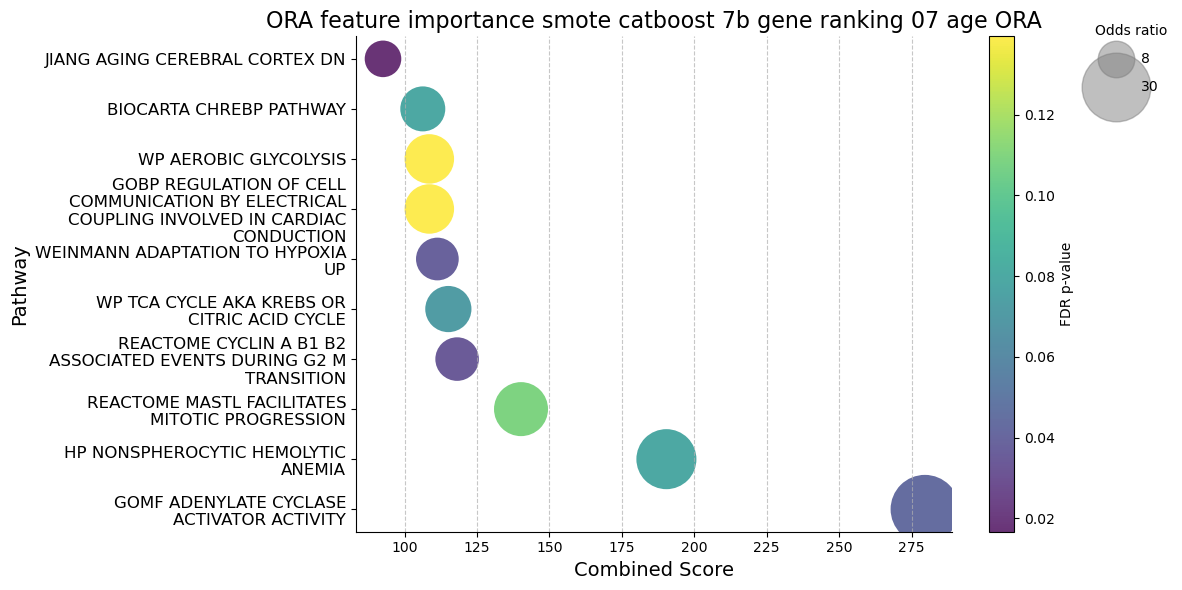

In [65]:
title = filename.replace("_"," ").replace(".csv","").replace("file","")
#title = title.replace("mf", "male vs female").replace("yo", "young vs old").replace("ym", "young vs middle age").replace("mo", "middle age vs old")
title = title.replace(" m ", " males ").replace(" f ", " females ")
fig, ax = plot_ora_results(ora_df, top_n=10, figsize=(12, 6), scale_odds_ratio=80, 
                     fontsize_title=16, fontsize_subtitle=14, fontsize_text=12,
                     fdr_bar_size=[0.8, 0.15, 0.03, 0.5], bbox_to_anchor=(1.3, 1.05), title=f"ORA {title}")
fig.savefig(f'results/{filename}_ORA_result.png')

In [18]:
file_dict=files_list[2]
filename= file_dict['filename']
path = file_dict['path']
# Generate the violin plot and return the figure
fig = prepare_ORA(filename=filename, path=path)

Non enough enriched pathways


## GSEA

In [75]:

# List to store dictionaries
files_list_gsea = []

# Iterate through the files in the directory
for filename in os.listdir(directory):
    if filename.endswith("GSEA.csv"):
        file_path = os.path.join(directory, filename)
        # Append the file information to the list as a dictionary
        files_list_gsea.append({"filename": filename, "path": file_path})
files_list_gsea

[{'filename': 'yo_F_file_GSEA.csv', 'path': '../data/yo_F_file_GSEA.csv'},
 {'filename': 'mo_file_GSEA.csv', 'path': '../data/mo_file_GSEA.csv'},
 {'filename': 'yo_file_GSEA.csv', 'path': '../data/yo_file_GSEA.csv'},
 {'filename': 'mo_F_file_GSEA.csv', 'path': '../data/mo_F_file_GSEA.csv'},
 {'filename': 'ym_F_file_GSEA.csv', 'path': '../data/ym_F_file_GSEA.csv'},
 {'filename': 'yo_M_file_GSEA.csv', 'path': '../data/yo_M_file_GSEA.csv'},
 {'filename': 'mf_m_file_GSEA.csv', 'path': '../data/mf_m_file_GSEA.csv'},
 {'filename': 'mf_y_file_GSEA.csv', 'path': '../data/mf_y_file_GSEA.csv'},
 {'filename': 'mf_o_file_GSEA.csv', 'path': '../data/mf_o_file_GSEA.csv'},
 {'filename': 'mo_M_file_GSEA.csv', 'path': '../data/mo_M_file_GSEA.csv'},
 {'filename': 'ym_M_file_GSEA.csv', 'path': '../data/ym_M_file_GSEA.csv'},
 {'filename': 'ym_file_GSEA.csv', 'path': '../data/ym_file_GSEA.csv'}]

In [101]:
import yaml
dds_files_path = '../data/dds_files.yml'
with open(dds_files_path, 'r') as file:
    dds_dict = yaml.safe_load(file)
df_dds_dict = {}

for dds, file in dds_dict.items():
    df = pd.read_csv(file, index_col=0)
    df_dds_dict[dds] =  df.copy()
df_dds_dict['yo_file']

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
TSPAN6,6.652061e+07,-0.039065,0.104623,-0.373394,0.708855,0.907432
TNMD,1.376112e+05,-0.426688,1.395668,-0.305723,0.759815,0.924157
DPM1,9.614235e+07,-0.145930,0.158111,-0.922960,0.356028,0.693475
SCYL3,1.268802e+07,-1.493229,0.706095,-2.114769,0.034450,0.158123
FIRRM,3.481744e+07,-1.009579,0.447366,-2.256718,0.024026,0.123501
...,...,...,...,...,...,...
C4orf36.1,5.664924e+07,-0.351695,0.220923,-1.591932,0.111400,0.346605
Unnamed: 34327,5.890034e+05,-0.088741,1.216048,-0.072975,0.941826,0.982119
H2BK1,9.477206e+05,0.010106,1.014972,0.009957,0.992056,0.997164
Unnamed: 34332,5.902246e+06,1.001606,0.743051,1.347965,0.177670,0.466165


In [105]:
missing=[]
files_list_gsea_new = []
for file in files_list_gsea[:]:
    base = file['filename'].replace('_GSEA.csv','')
    file['scores'] = df_dds_dict[base]
    files_list_gsea_new.append(file)
files_list_gsea= files_list_gsea_new

In [ ]:
work/data/RNAseq_abundances_adjusted_combat_inmose_young.vs.old_DDS.csv

In [82]:
files_list_gsea = [
{'filename': 'Catboost 7%',
  'path': '../data/feature_importance_smote_catboost_7b_gene_ranking_07_age_GSEA.csv',
  'score':'../data/feature_importance_smote_catboost_7b_gene_ranking_07.csv',
  'score_name':'coef'},

 {'filename': 'Ridge 40%',
  'path': '../data/feature_importance_ridge_smote_7b_age_GSEA.csv',
  'score': '../data/feature_importance_ridge_smote_7b_SYMBOLS.csv',
 'score_name':'Importance'},

  {'filename': 'Differential expression young vs middle age',
  'path': '../data/RNAseq_abundances_adjusted_combat_inmose_young.vs.middle_GSEA.csv',
  'score': '../data/RNAseq_abundances_adjusted_combat_inmose_young.vs.middle_DDS.csv',
  'score_name':'stat'},

   {'filename': 'Differential expression middle age vs old',
  'path': '../data/RNAseq_abundances_adjusted_combat_inmose_middle.vs.old_GSEA.csv',
  'score': '../data/RNAseq_abundances_adjusted_combat_inmose_middle.vs.old_DDS.csv',
  'score_name':'stat'},

   {'filename': 'Differential expression young vs old',
  'path': '../data/RNAseq_abundances_adjusted_combat_inmose_young.vs.old_GSEA.csv',
  'score': '../data/RNAseq_abundances_adjusted_combat_inmose_young.vs.old_DDS.csv',
  'score_name':'stat'}
 ]

In [80]:
msigdb_extended=pd.read_csv('../data/msigdb_extended.csv')

/tmp/ipykernel_186982/3954172370.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  msigdb_extended=pd.read_csv('../data/msigdb_extended.csv')


In [76]:
def get_terms_interest(filename, path):
    gsea_df = pd.read_csv(path, index_col=0)
    gsea_df=gsea_df[gsea_df['FDR p-value']<gsea_fdr]
    gsea_df=gsea_df[abs(gsea_df['NES'])>gsea_nes]
    terms = gsea_df['Term']
    return list(terms)
    

In [84]:

def get_gsea_figure(filename,score_file,score_name,msigdb,term):
    
        fig,ax = plot_gsea_results(gsea_scores=gsea_scores, score_name=score_name, msigdb=msigdb, term=term)
    else:
        print("not enough enriched pathways")
        return None
    
    return fig, ax
    

running yo_F_file_GSEA.csv
yo_F_file_GSEA.csv has 11037 pathways enriched
yo_F_file_GSEA.csv: Checking term BRUECKNER_TARGETS_OF_MIRLET7A3_UP
yo_F_file_GSEA.csv: Checking term MIR149_5P
yo_F_file_GSEA.csv: Checking term AAGCAAT_MIR137
yo_F_file_GSEA.csv: Checking term HALLMARK_G2M_CHECKPOINT
yo_F_file_GSEA.csv: Checking term GSE3920_IFNB_VS_IFNG_TREATED_ENDOTHELIAL_CELL_DN
yo_F_file_GSEA.csv: Checking term HP_DILATED_CARDIOMYOPATHY
yo_F_file_GSEA.csv: Checking term MIR4789_5P
yo_F_file_GSEA.csv: Checking term GSE25088_WT_VS_STAT6_KO_MACROPHAGE_ROSIGLITAZONE_STIM_UP
yo_F_file_GSEA.csv: Checking term HP_EXCESSIVE_SALIVATION
yo_F_file_GSEA.csv: Checking term GSE11864_UNTREATED_VS_CSF1_IFNG_IN_MAC_DN
running mo_file_GSEA.csv
mo_file_GSEA.csv has 16252 pathways enriched
mo_file_GSEA.csv: Checking term GSE22886_TH1_VS_TH2_48H_ACT_DN
mo_file_GSEA.csv: Checking term RICKMAN_HEAD_AND_NECK_CANCER_C
mo_file_GSEA.csv: Checking term HP_ABNORMAL_BLOOD_GLUCOSE_CONCENTRATION
mo_file_GSEA.csv: Checking

/opt/conda/lib/python3.11/site-packages/decoupler/plotting.py:1254: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(4, 1, gridspec_kw={'height_ratios': [4, 0.5, 0.5, 2]}, figsize=figsize, sharex=True, dpi=dpi)


yo_file_GSEA.csv: Checking term GSE5542_IFNA_VS_IFNA_AND_IFNG_TREATED_EPITHELIAL_CELLS_6H_UP
yo_file_GSEA.csv: Checking term GSE15659_RESTING_VS_ACTIVATED_TREG_DN
yo_file_GSEA.csv: Checking term GSE14769_40MIN_VS_360MIN_LPS_BMDM_DN
yo_file_GSEA.csv: Checking term CERVERA_SDHB_TARGETS_1_UP
yo_file_GSEA.csv: Checking term GSE28726_NAIVE_CD4_TCELL_VS_NAIVE_NKTCELL_DN
yo_file_GSEA.csv: Checking term WP_NONGENOMIC_ACTIONS_OF_125_DIHYDROXYVITAMIN_D3
yo_file_GSEA.csv: Checking term GOBP_NEGATIVE_REGULATION_OF_WNT_SIGNALING_PATHWAY
yo_file_GSEA.csv: Checking term MIR3129_3P
yo_file_GSEA.csv: Checking term GSE28237_EARLY_VS_LATE_GC_BCELL_UP
running mo_F_file_GSEA.csv
mo_F_file_GSEA.csv has 4005 pathways enriched
mo_F_file_GSEA.csv: Checking term FAN_OVARY_CL7_ANGEIOGENIC_ENDOTHELIAL_CELL
mo_F_file_GSEA.csv: Checking term GSE339_CD4POS_VS_CD4CD8DN_DC_UP
mo_F_file_GSEA.csv: Checking term AIZARANI_LIVER_C21_STELLATE_CELLS_1
mo_F_file_GSEA.csv: Checking term GOBP_RESPONSE_TO_PURINE_CONTAINING_COMPO

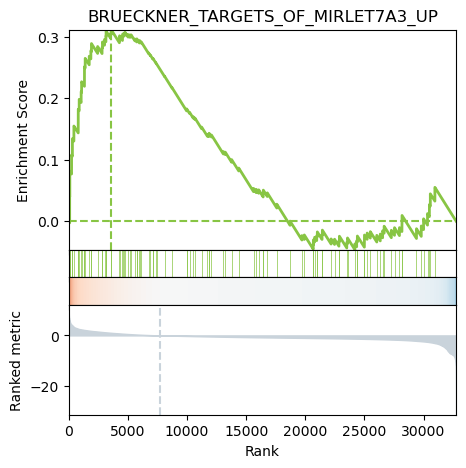

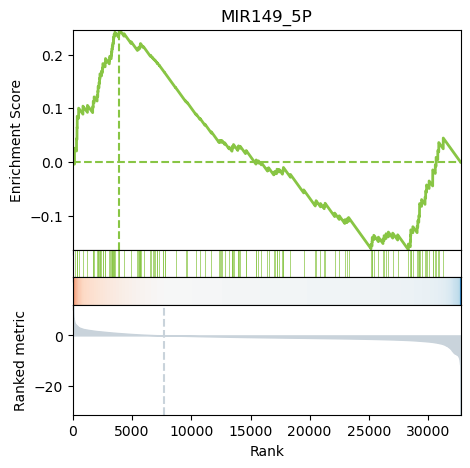

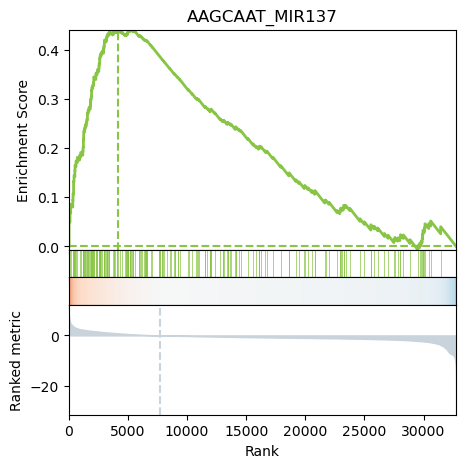

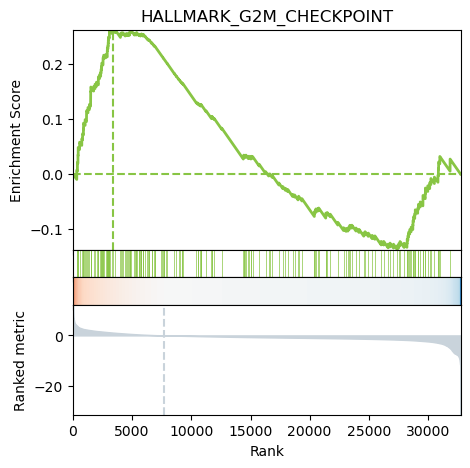

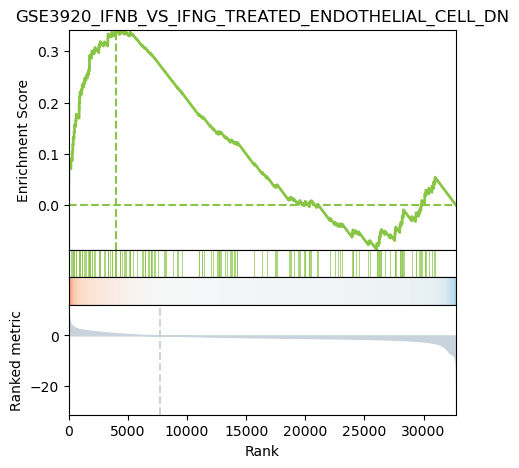

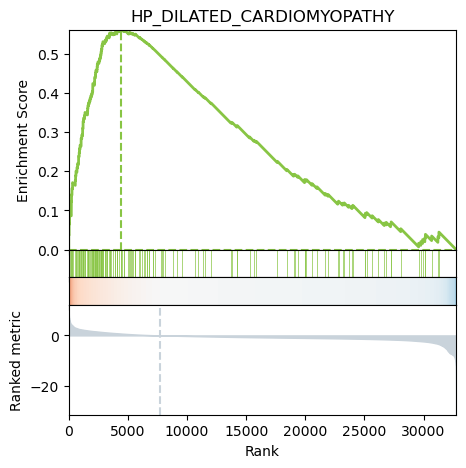

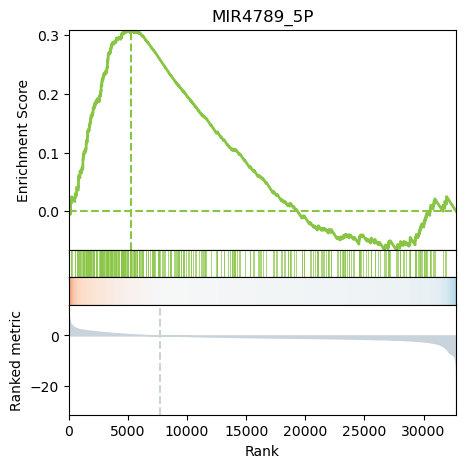

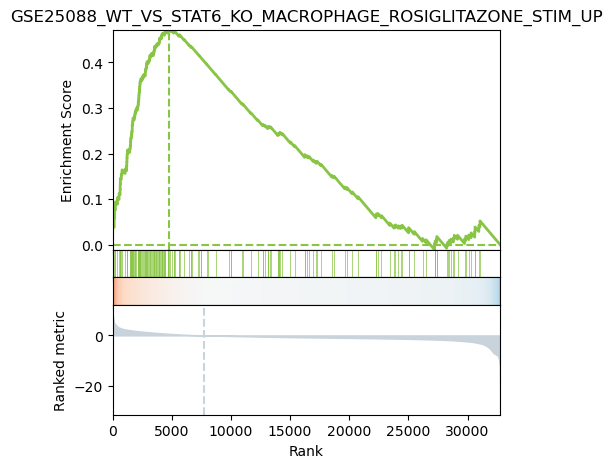

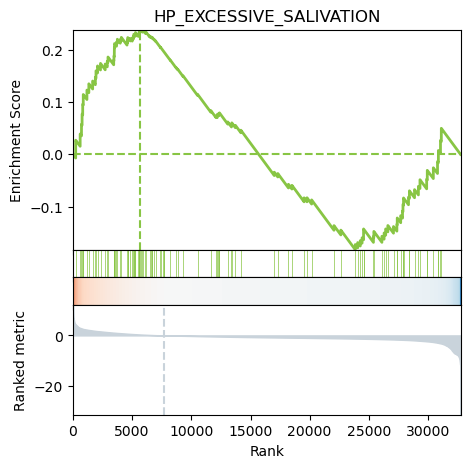

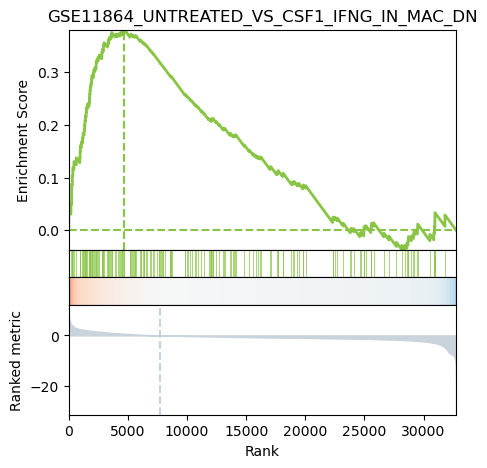

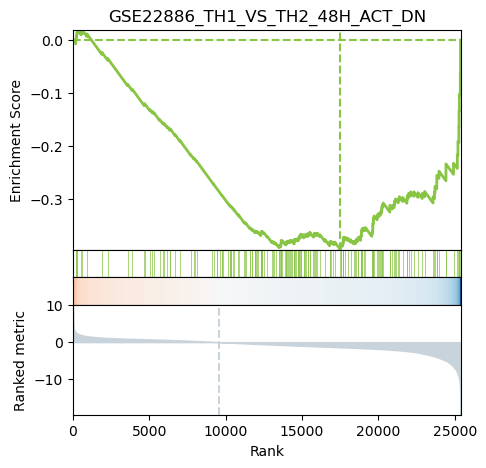

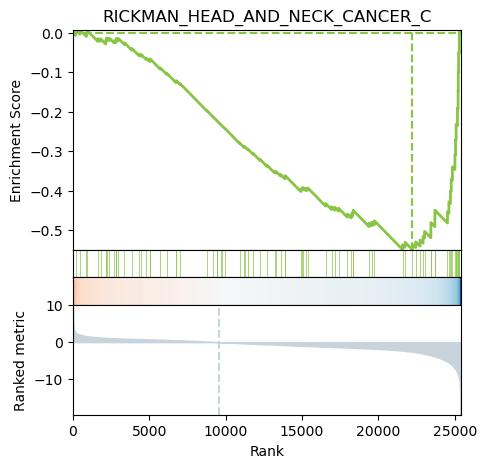

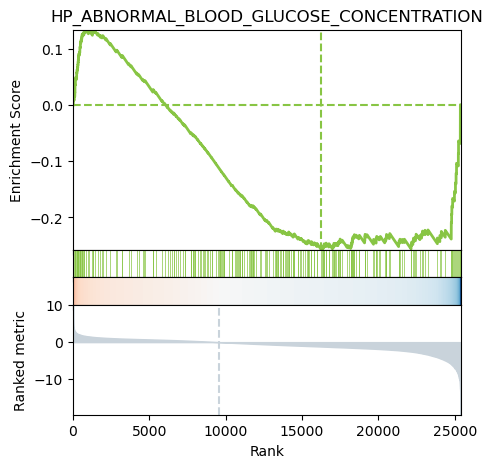

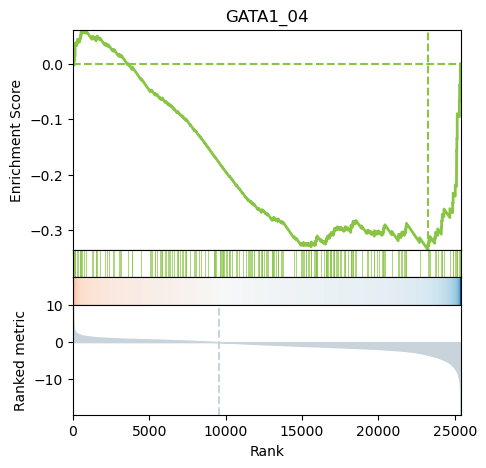

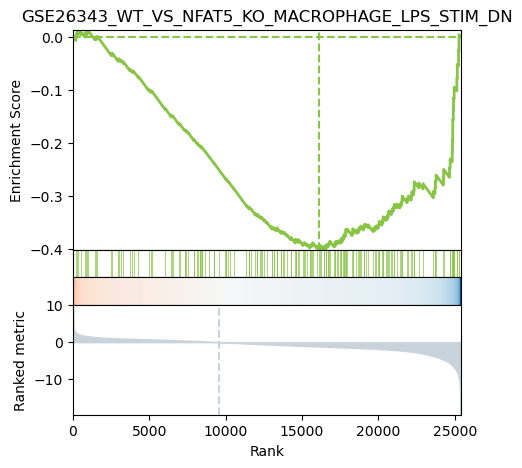

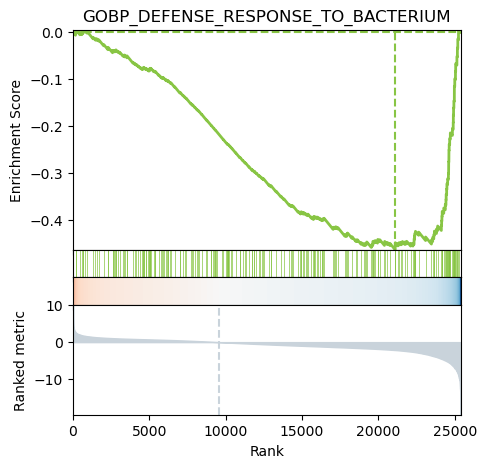

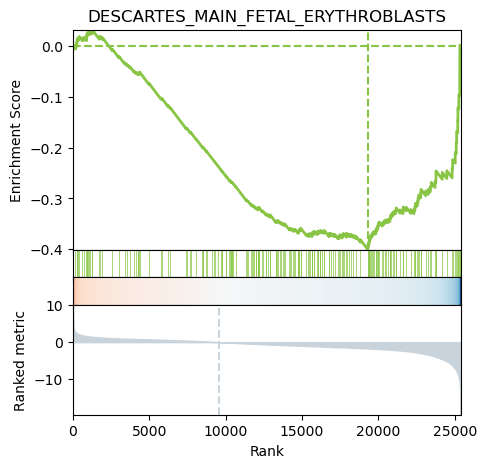

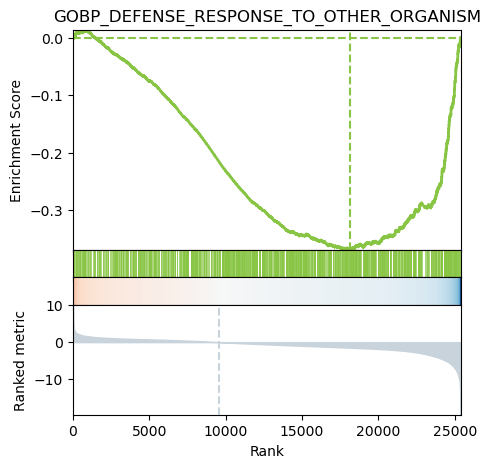

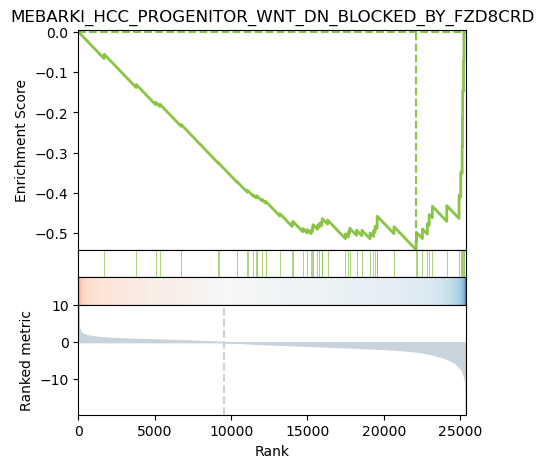

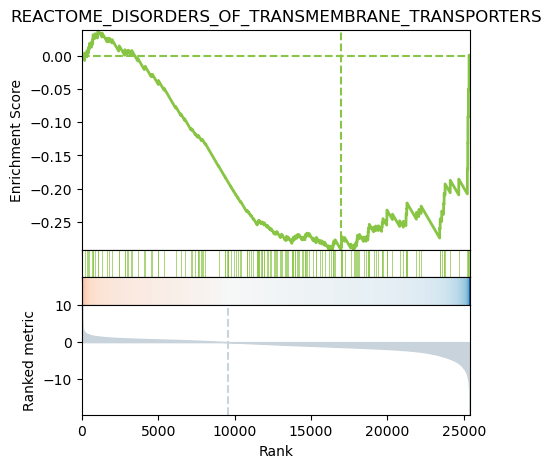

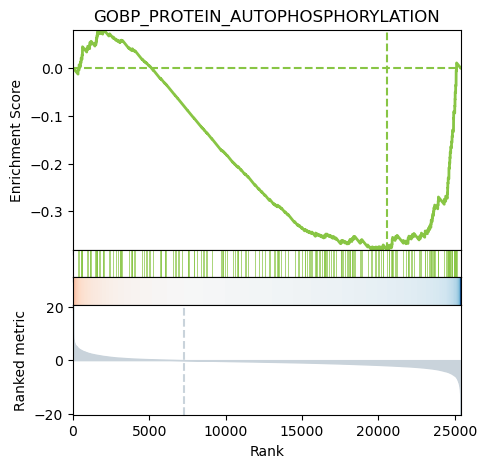

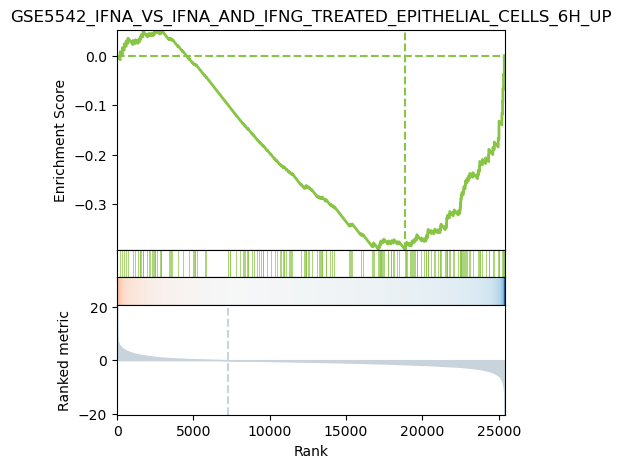

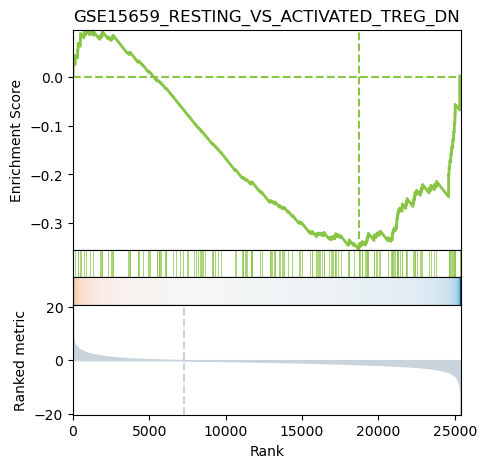

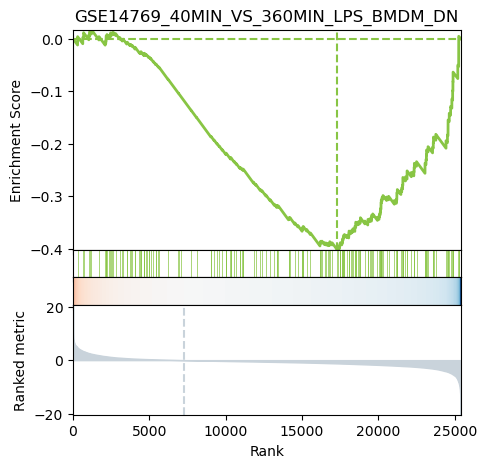

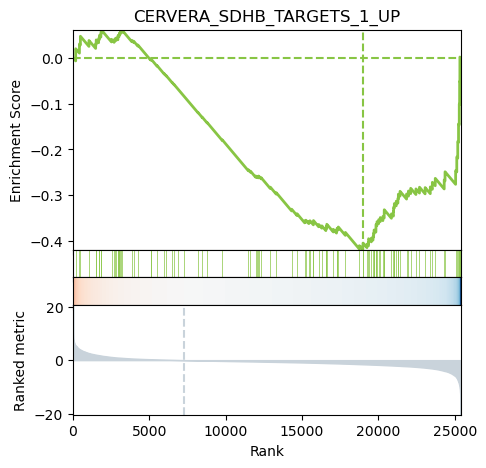

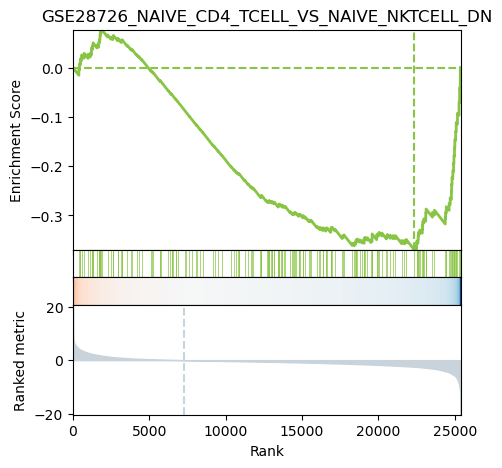

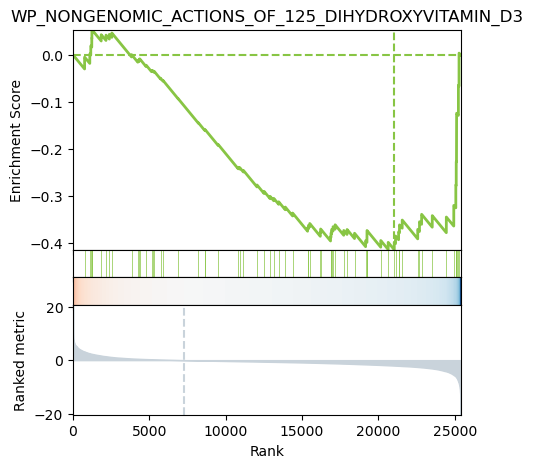

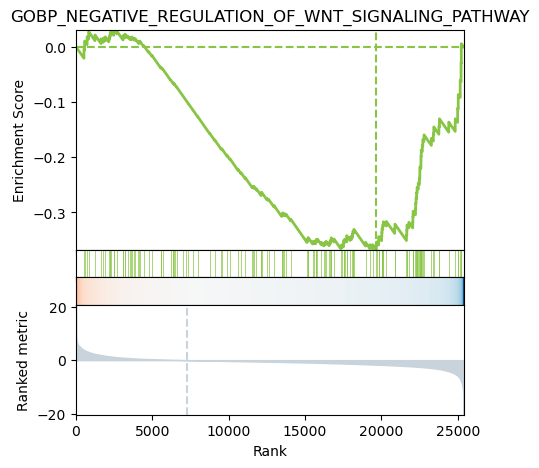

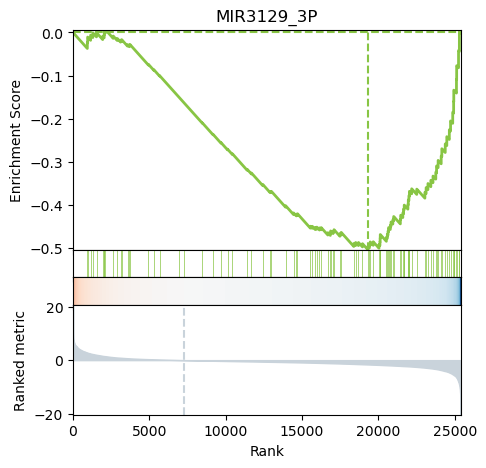

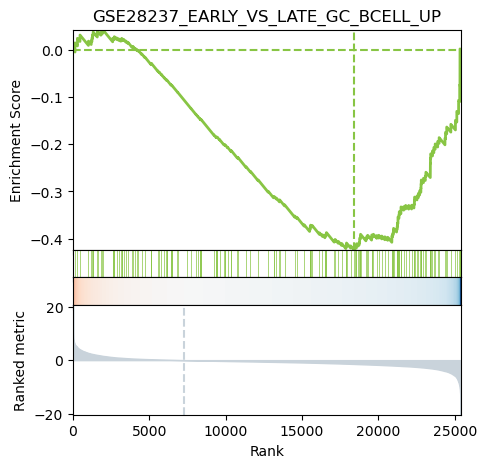

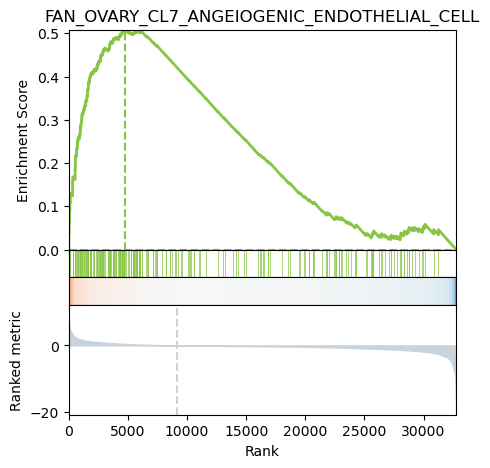

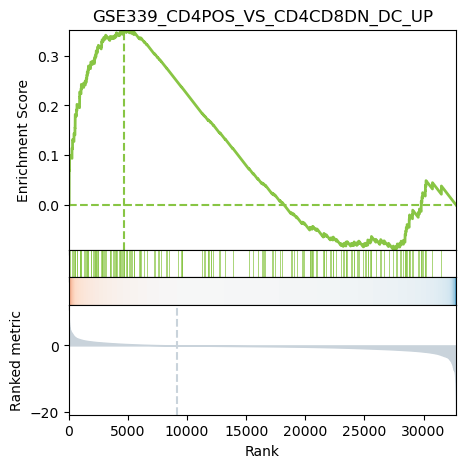

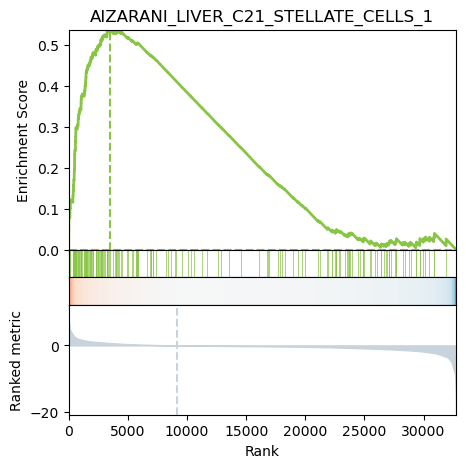

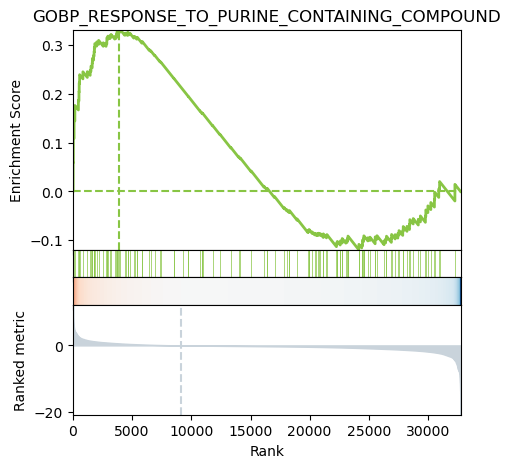

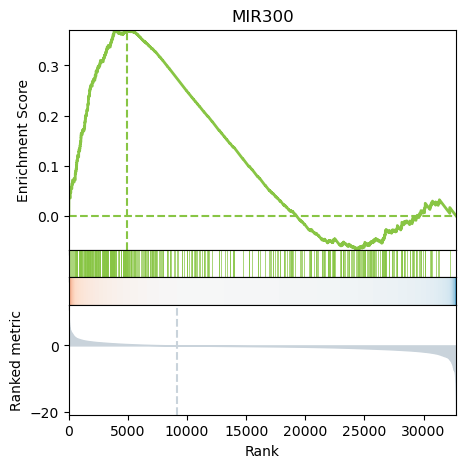

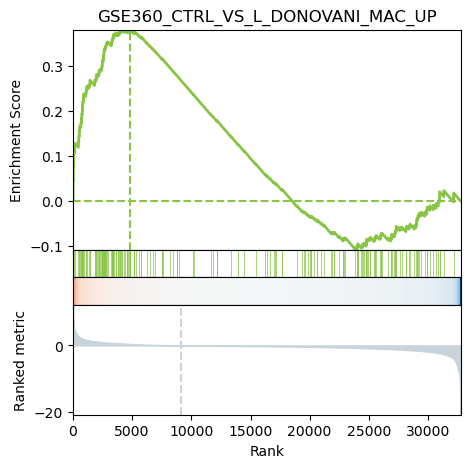

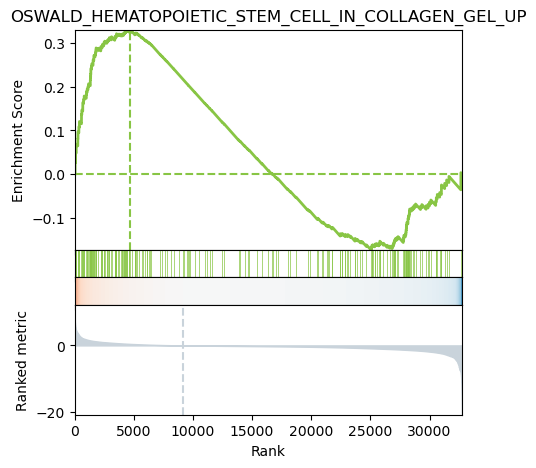

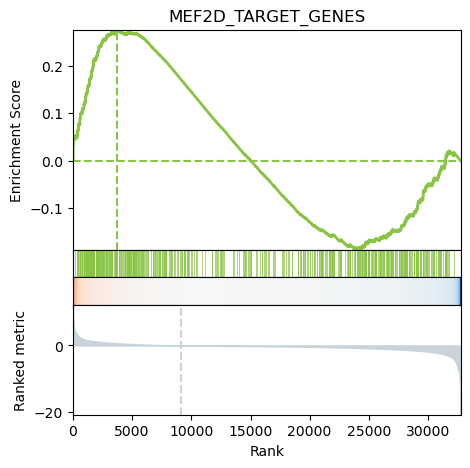

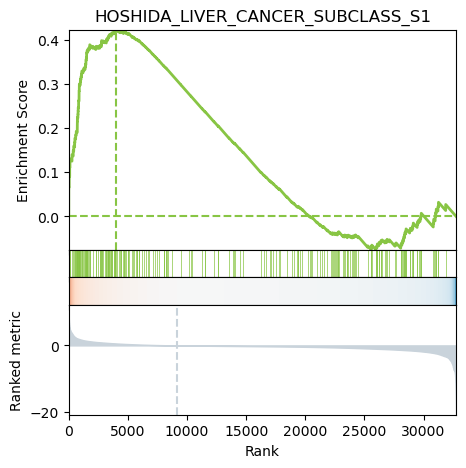

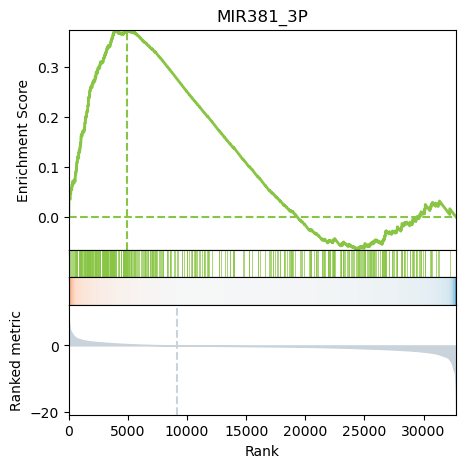

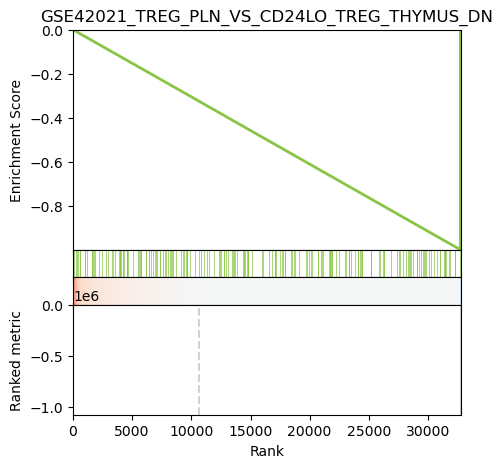

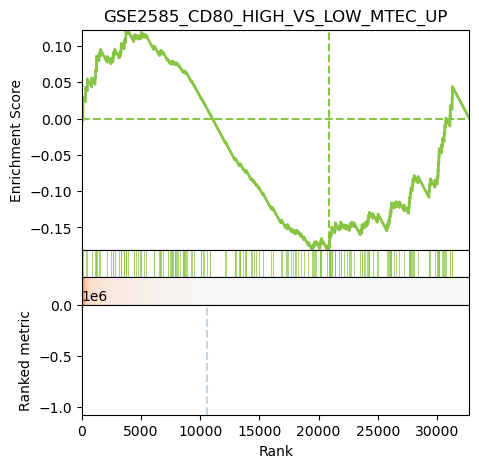

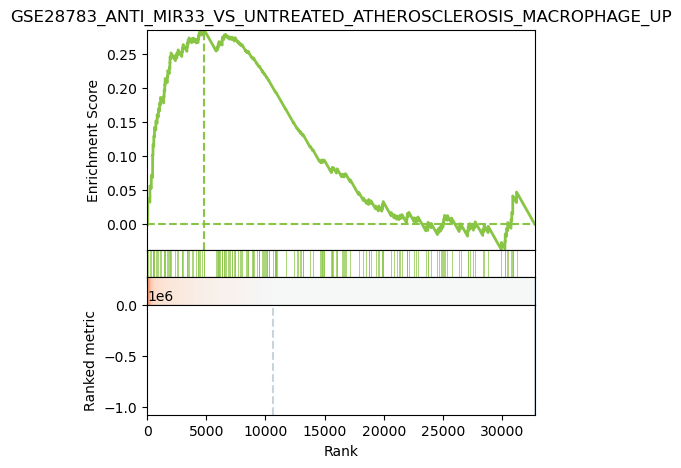

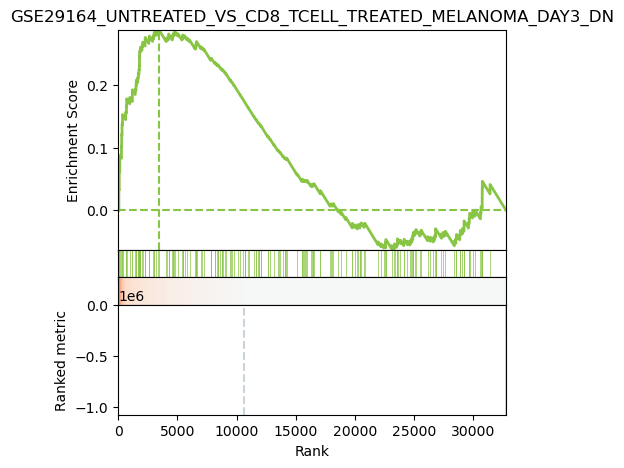

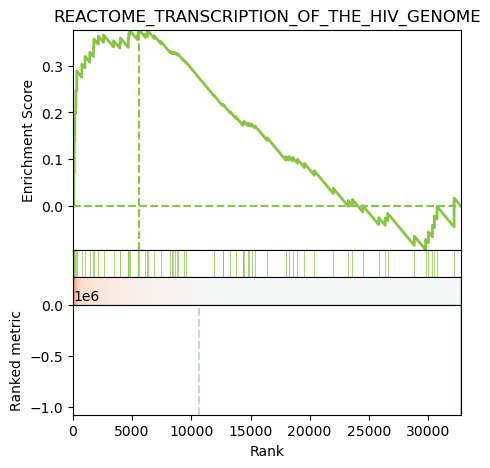

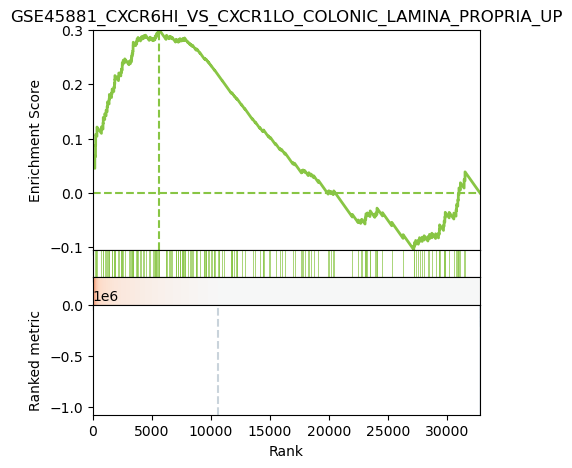

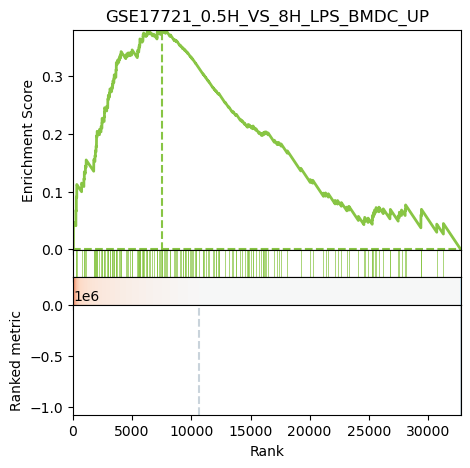

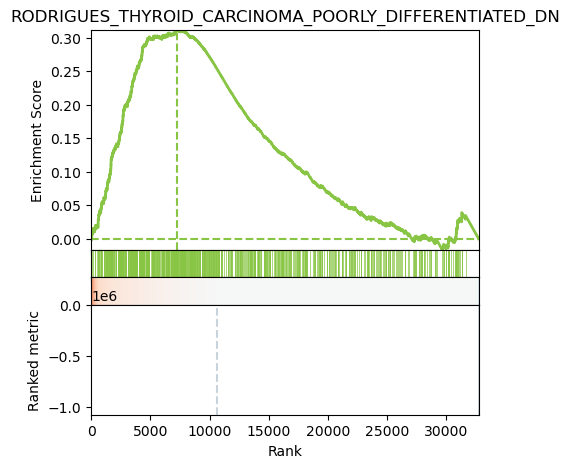

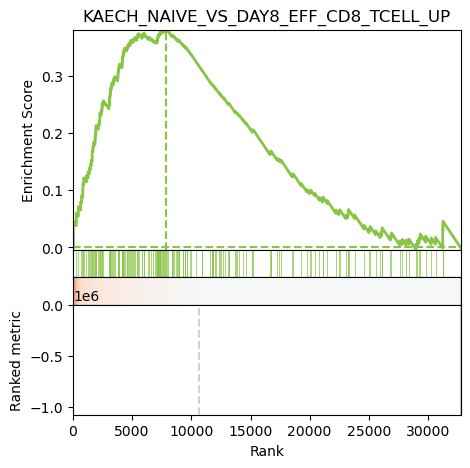

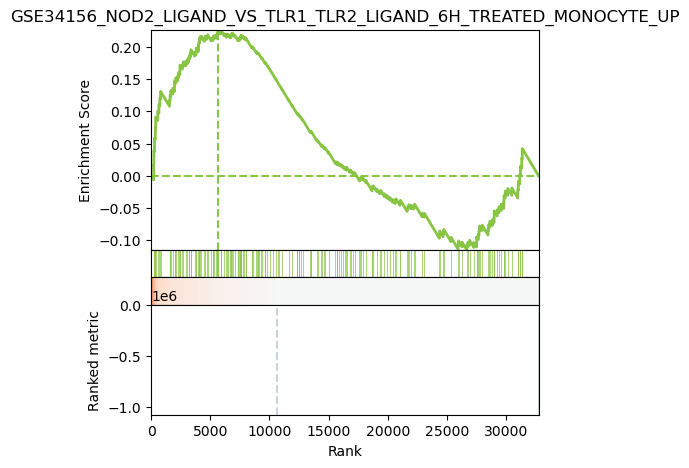

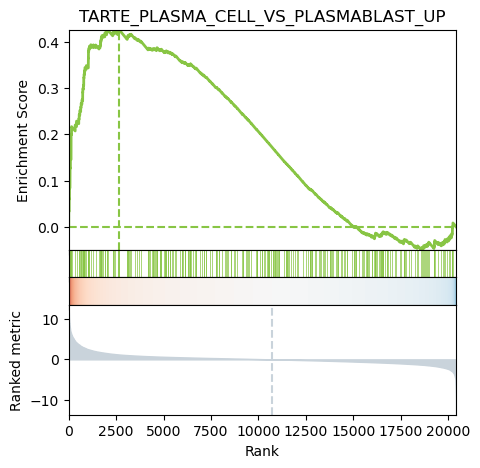

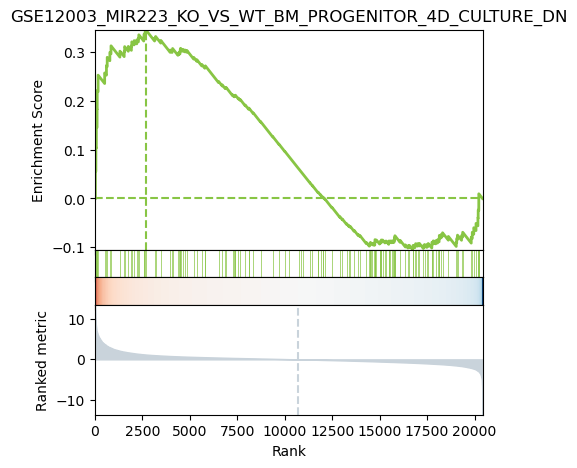

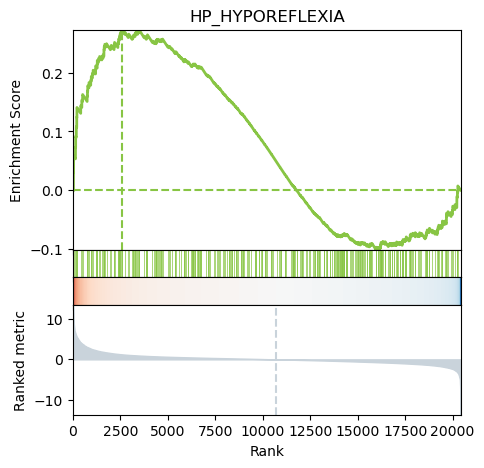

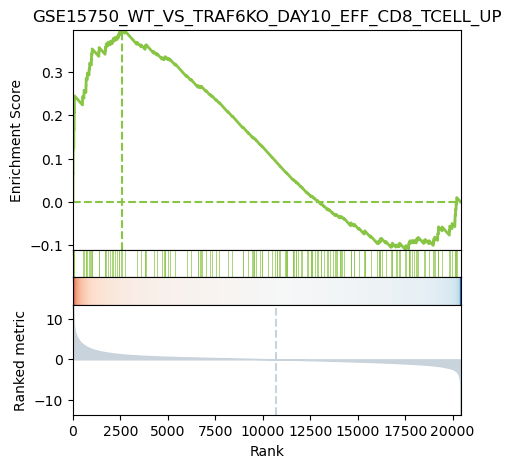

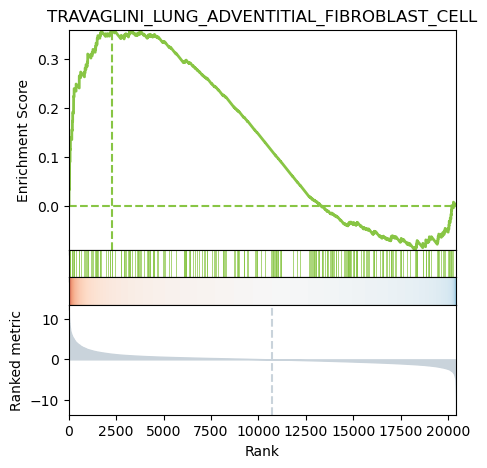

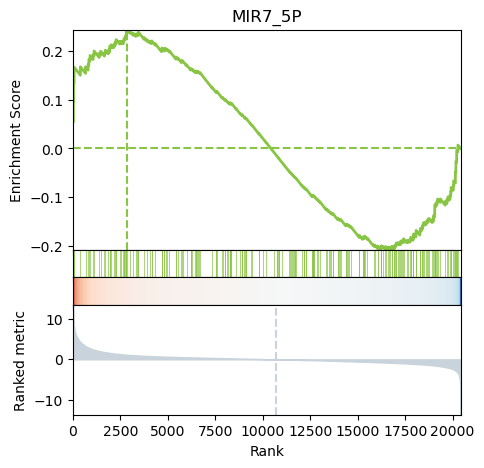

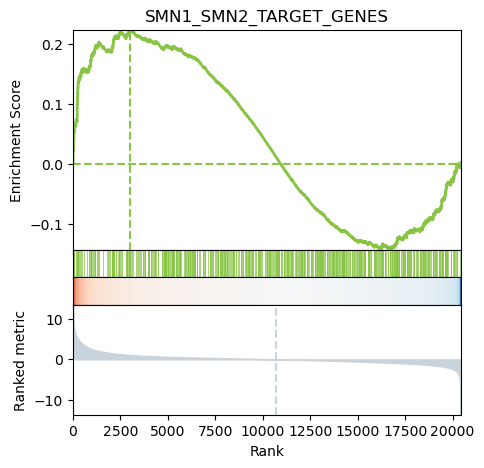

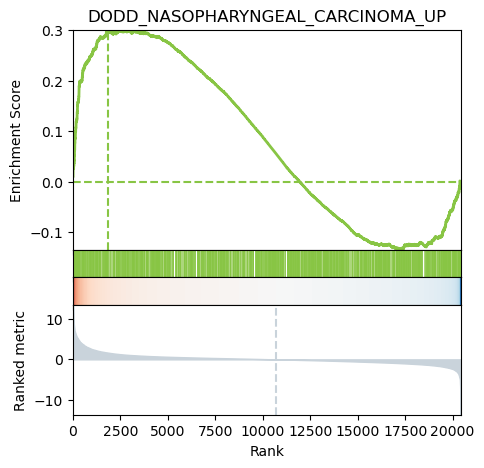

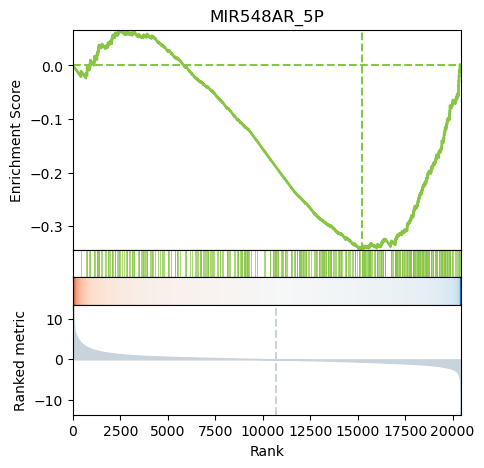

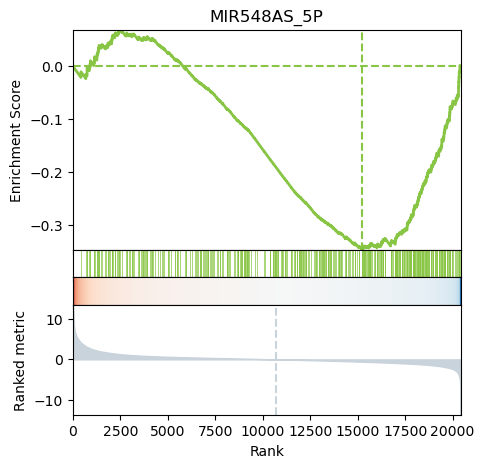

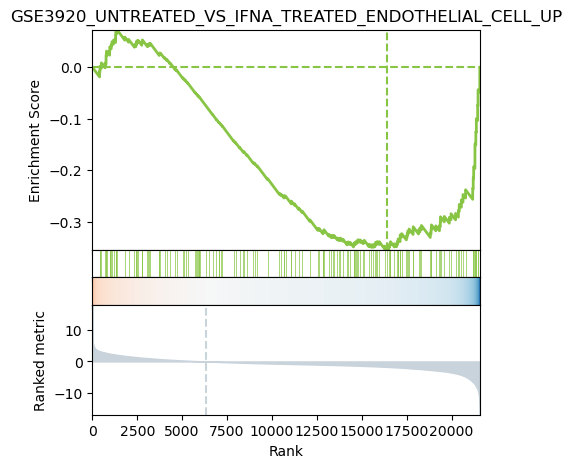

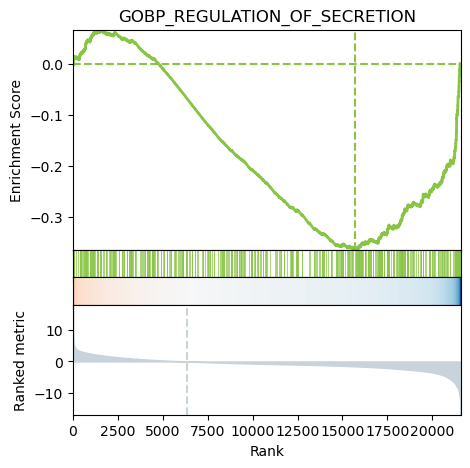

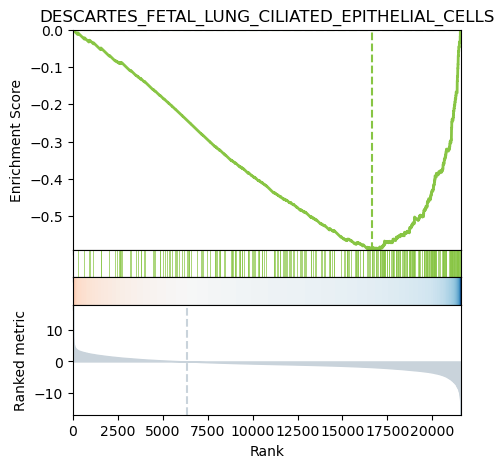

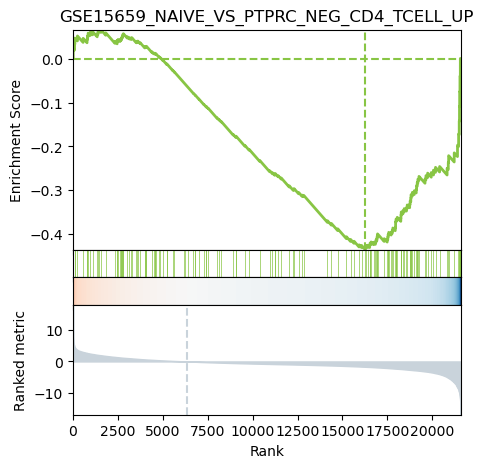

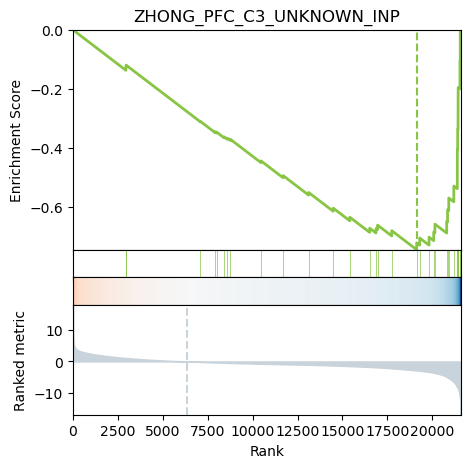

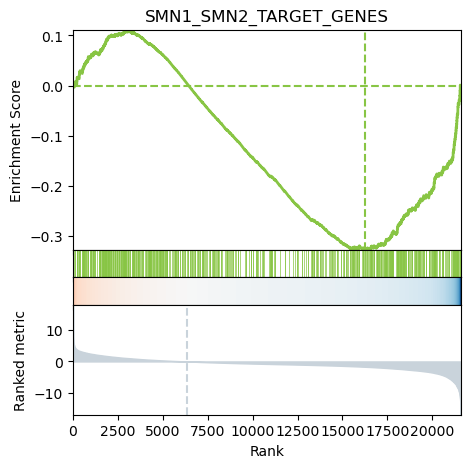

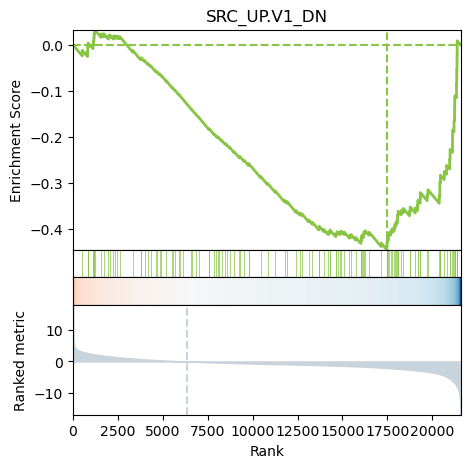

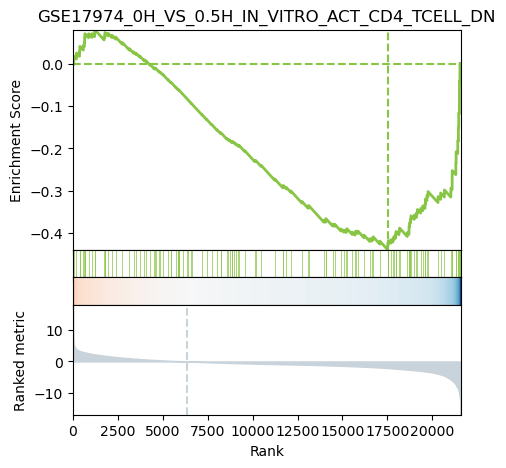

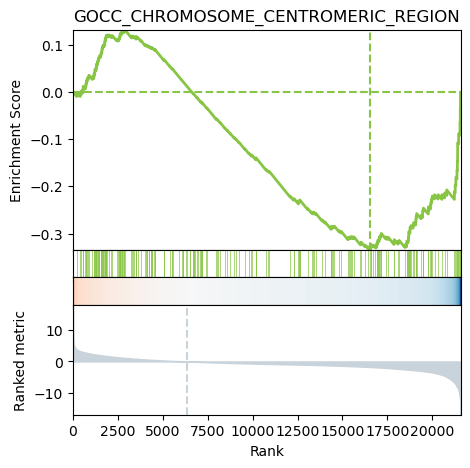

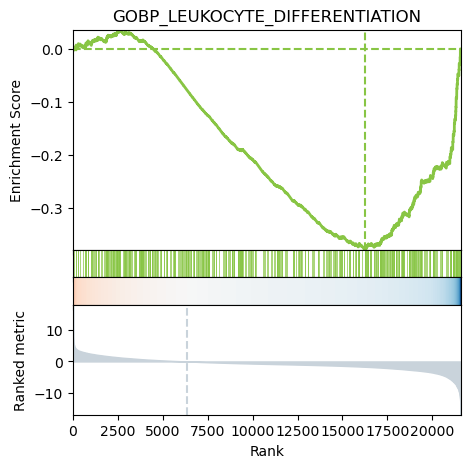

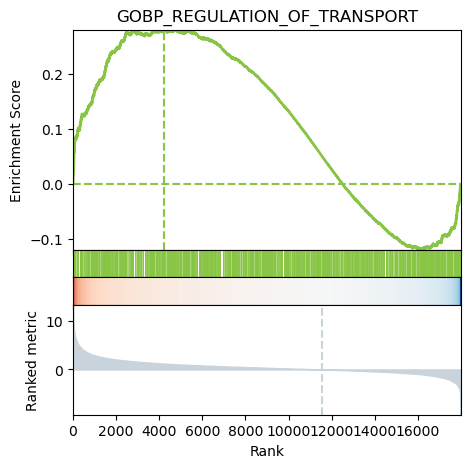

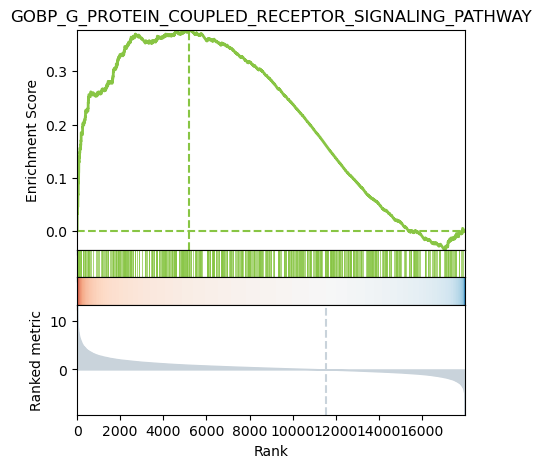

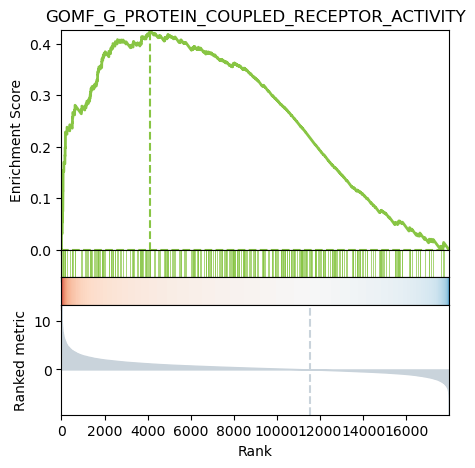

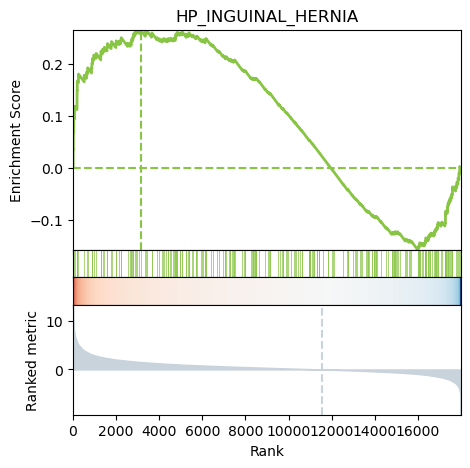

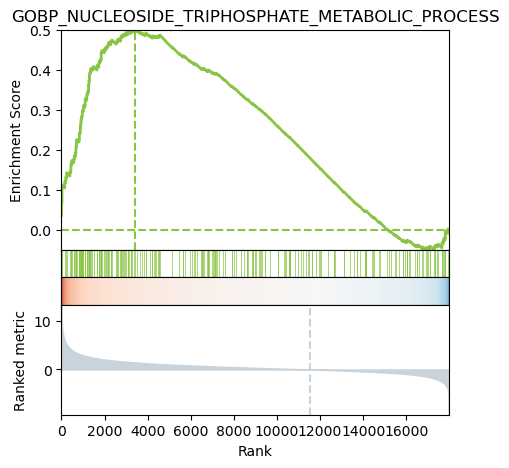

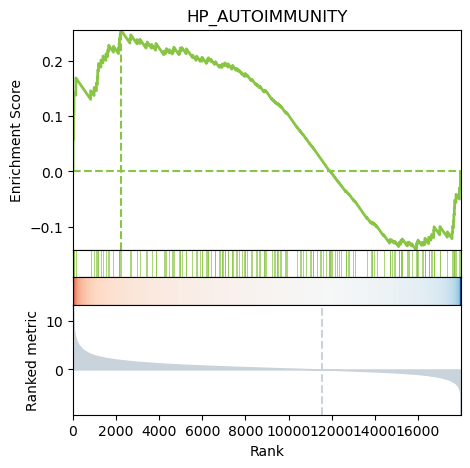

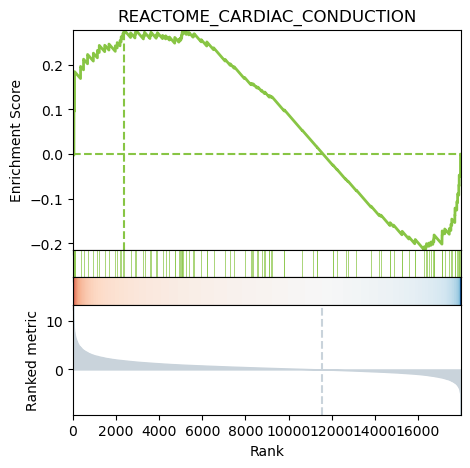

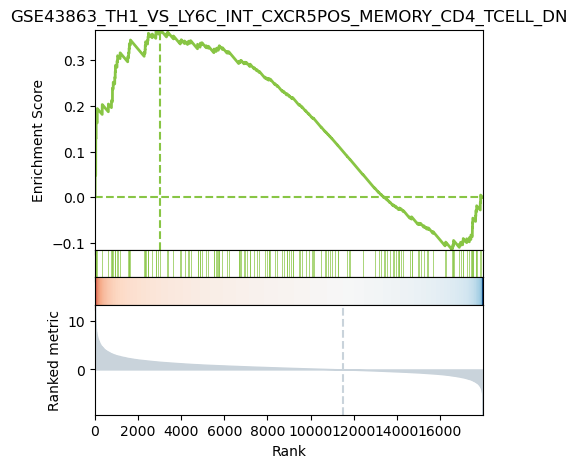

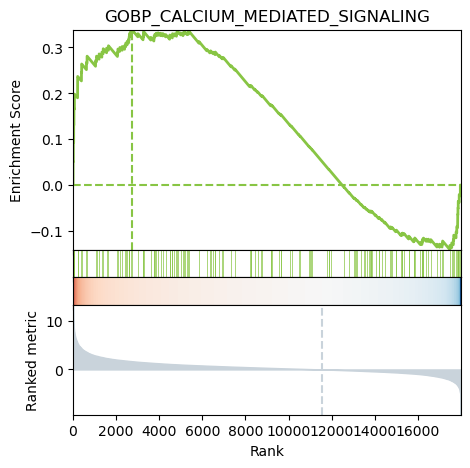

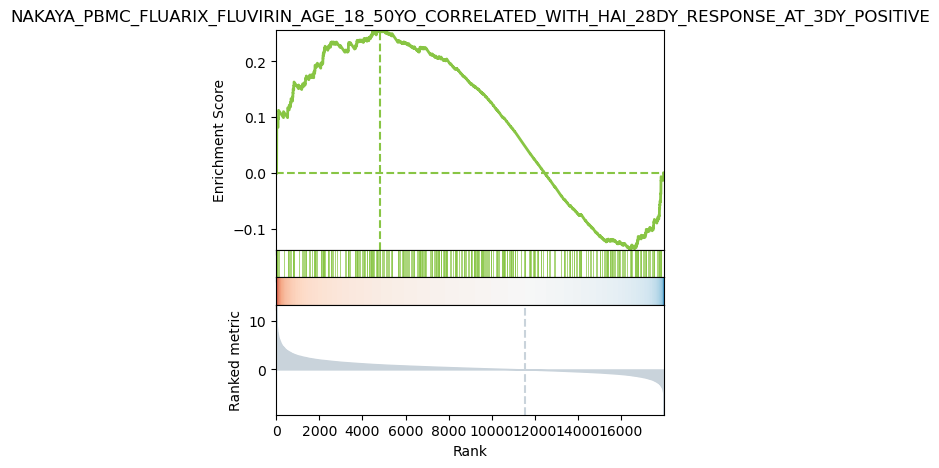

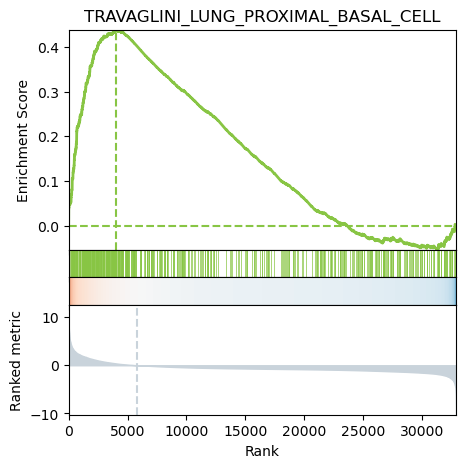

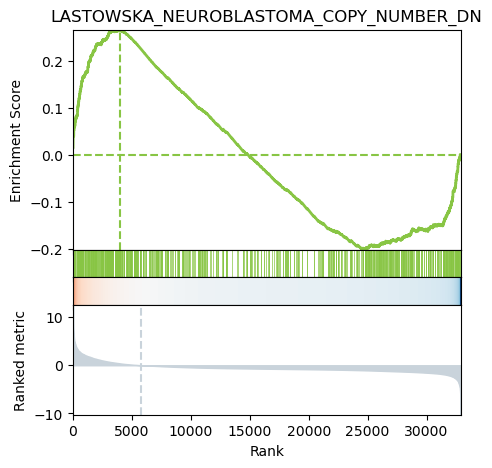

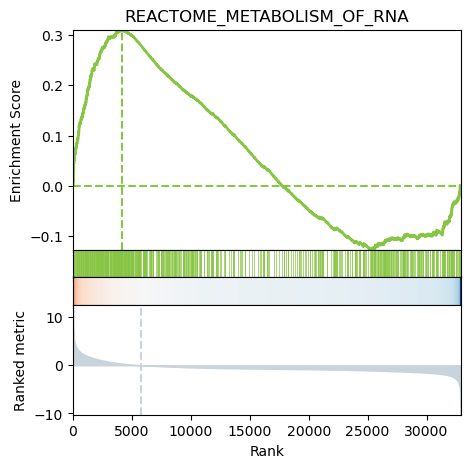

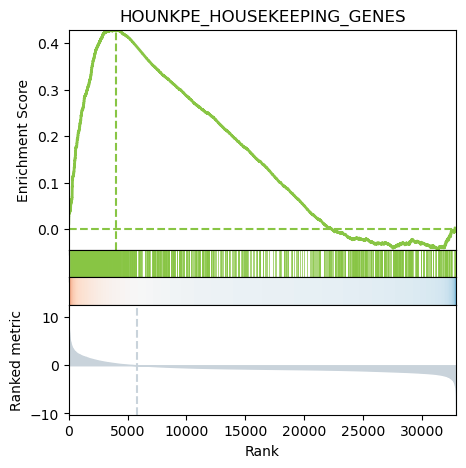

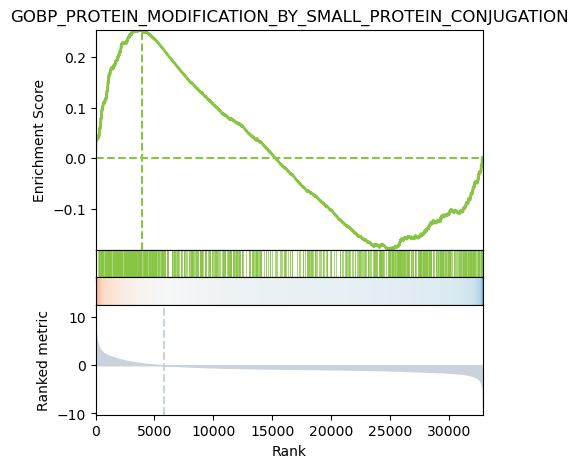

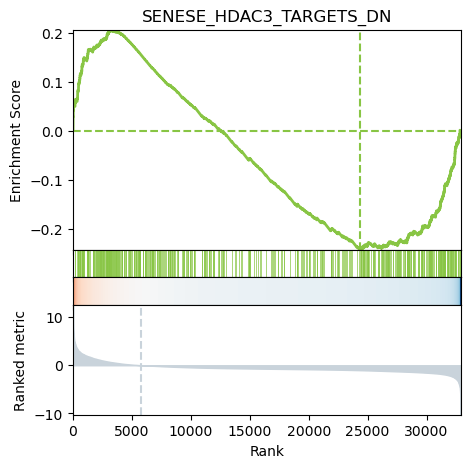

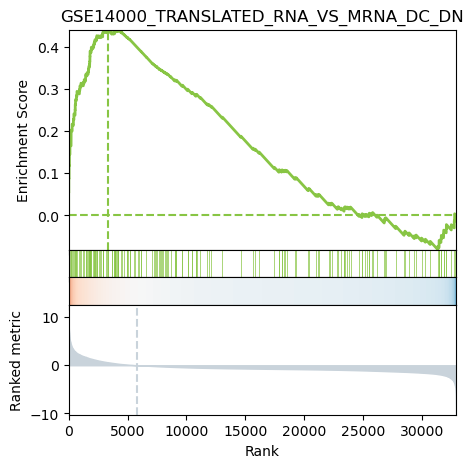

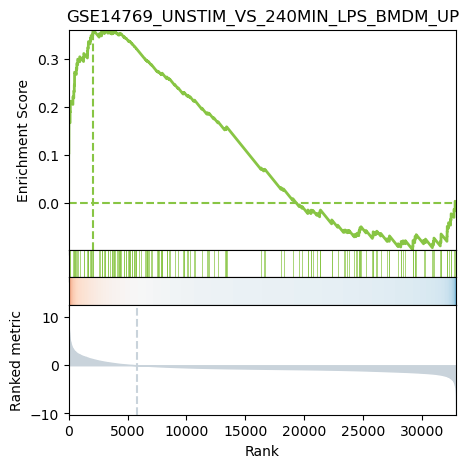

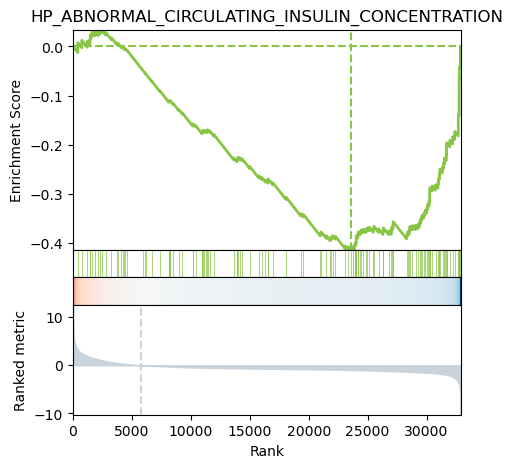

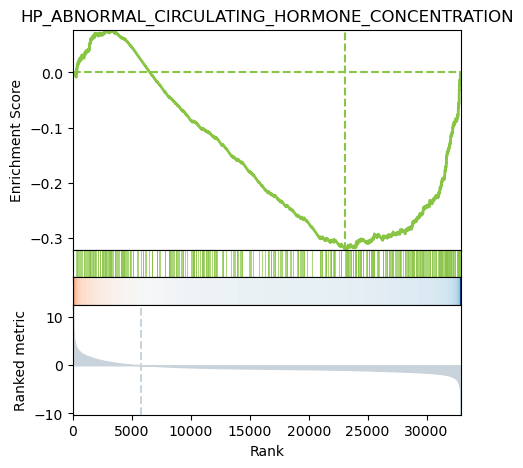

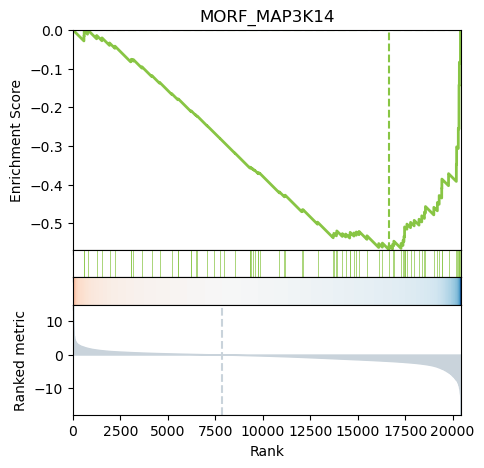

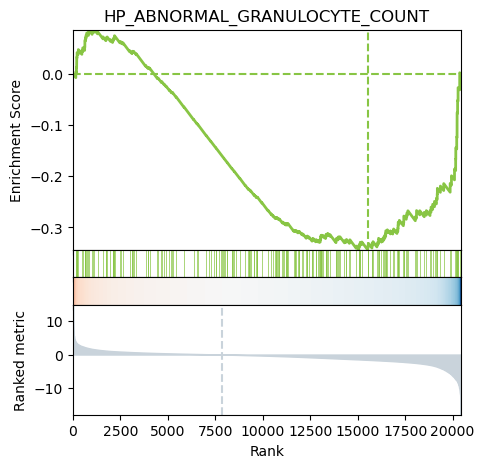

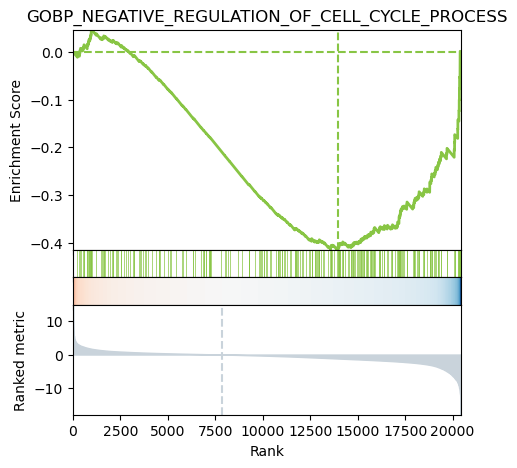

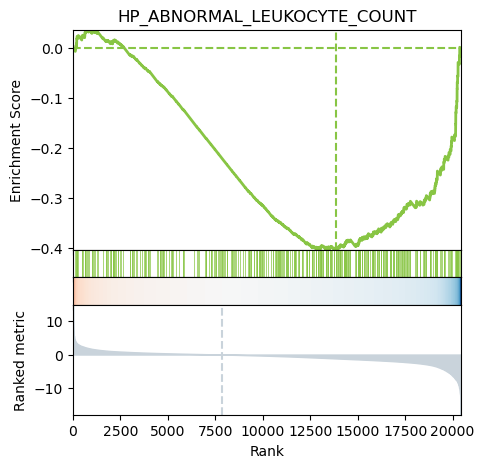

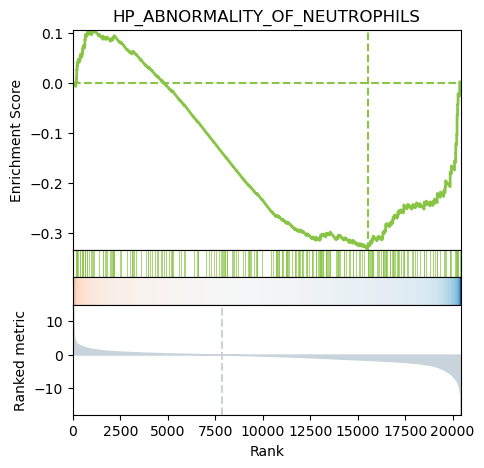

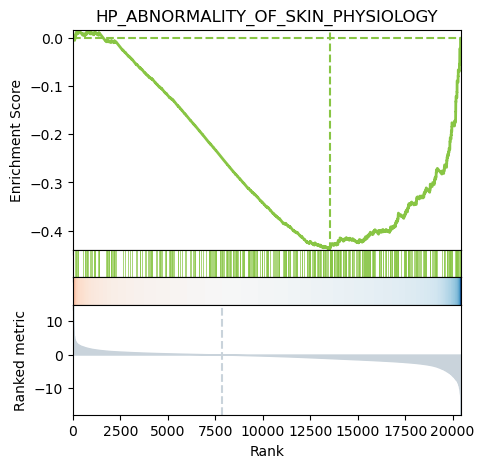

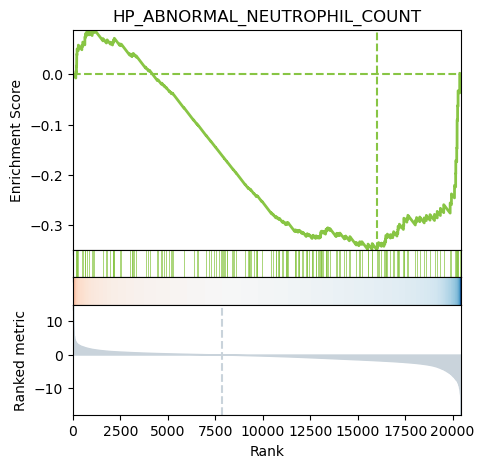

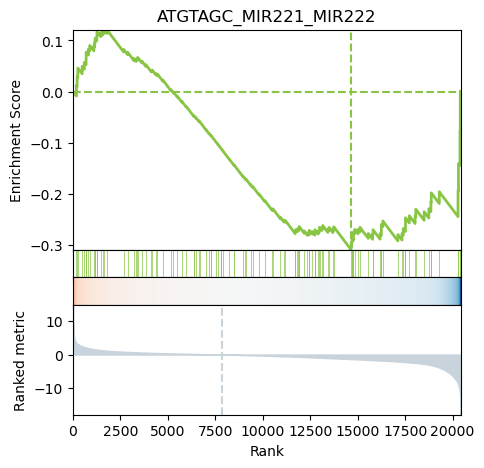

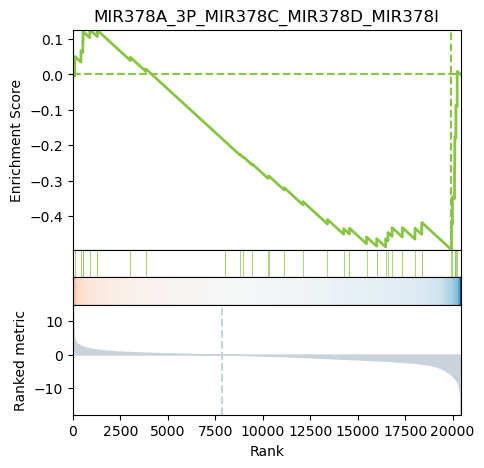

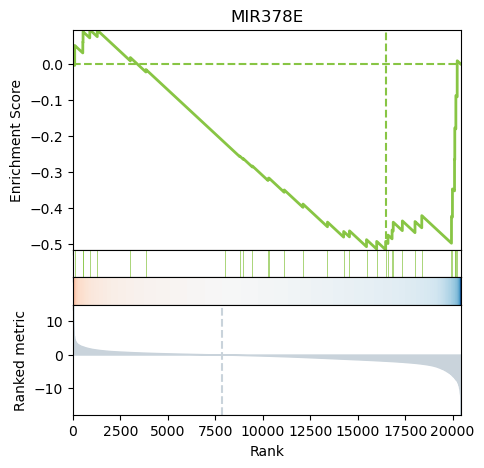

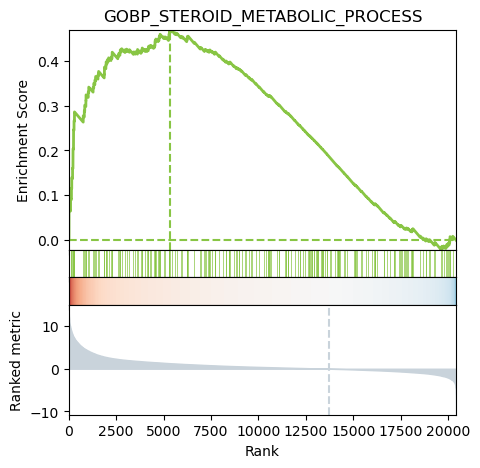

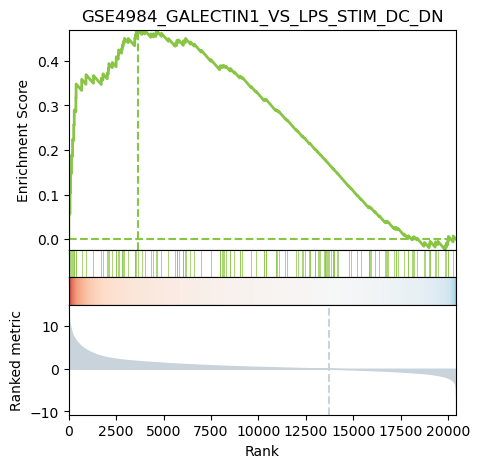

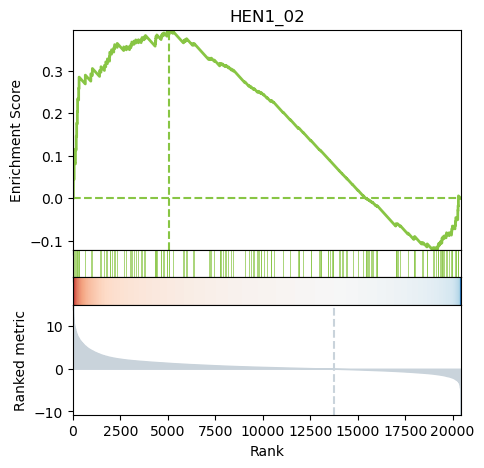

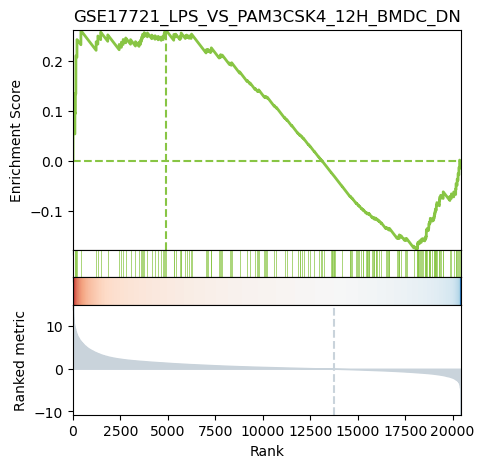

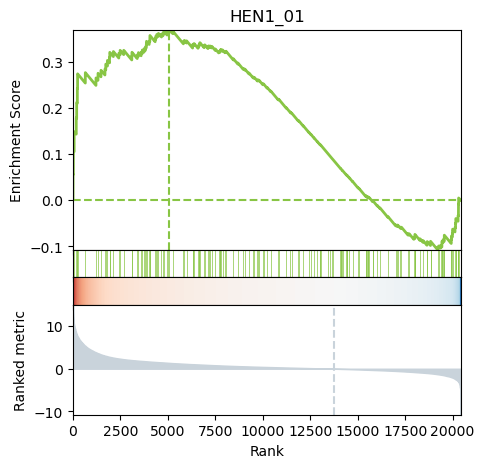

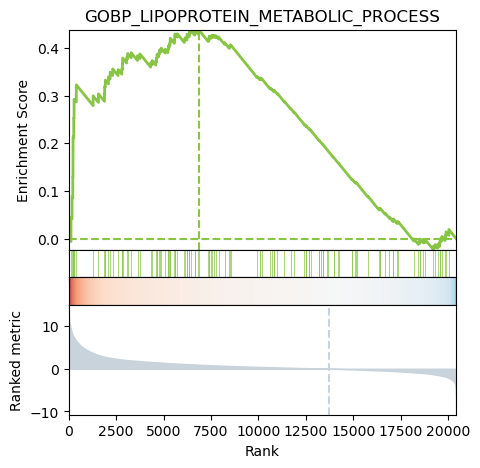

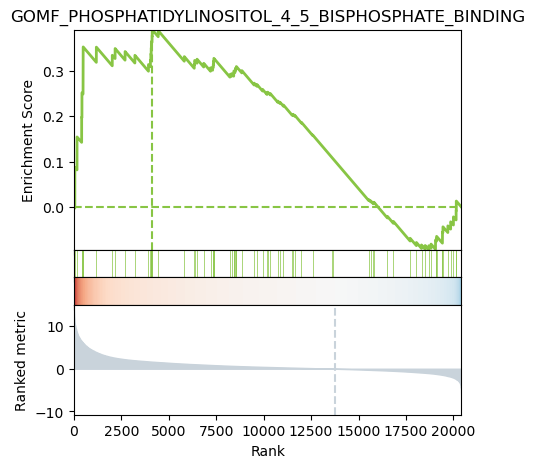

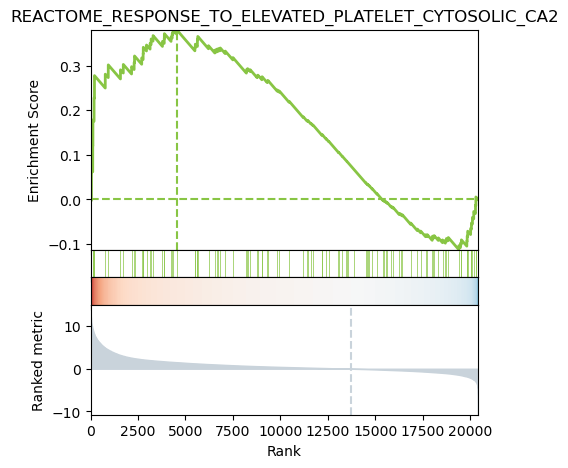

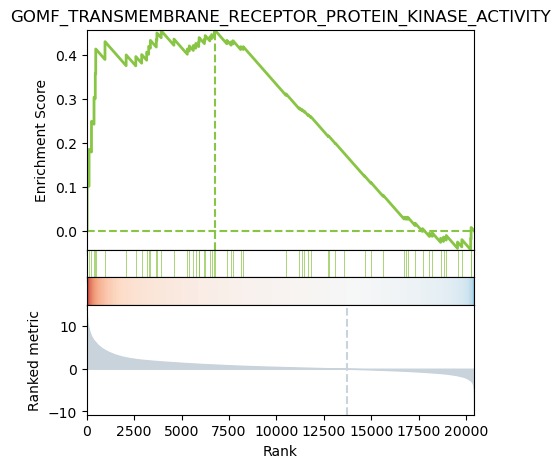

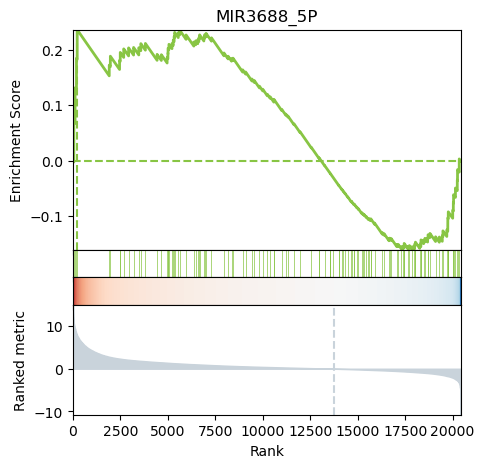

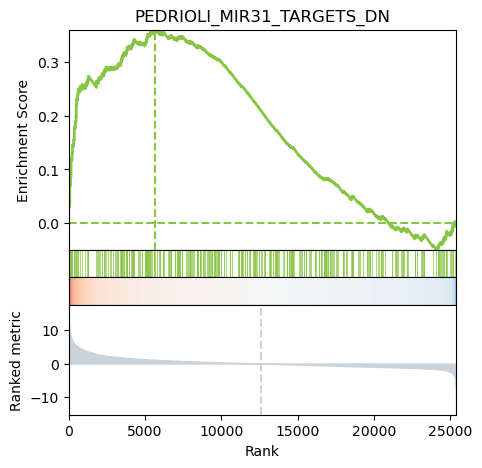

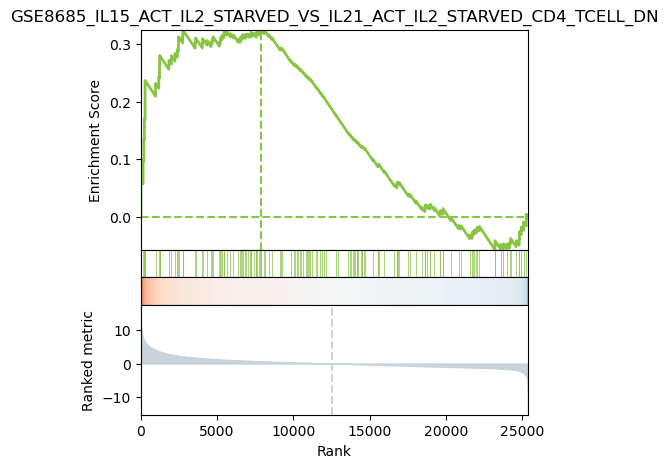

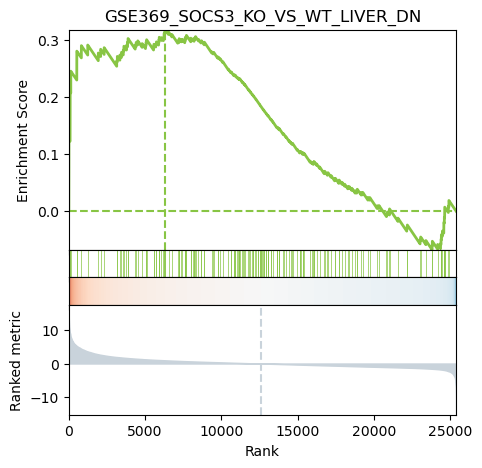

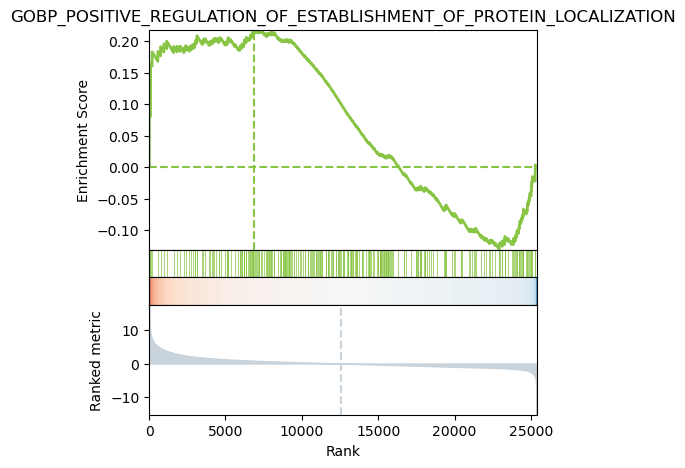

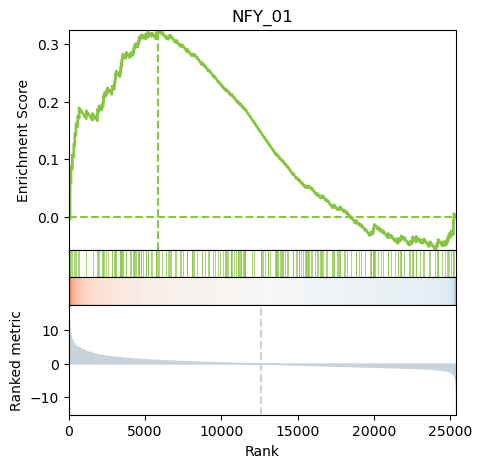

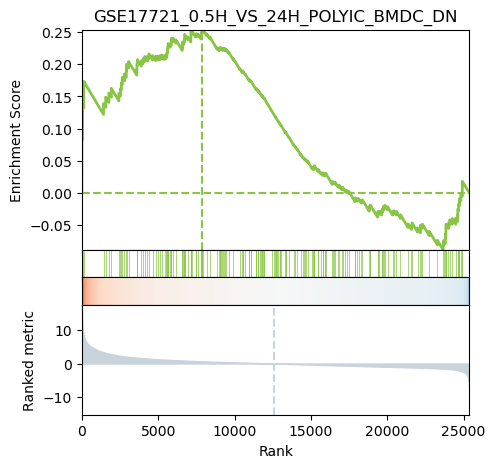

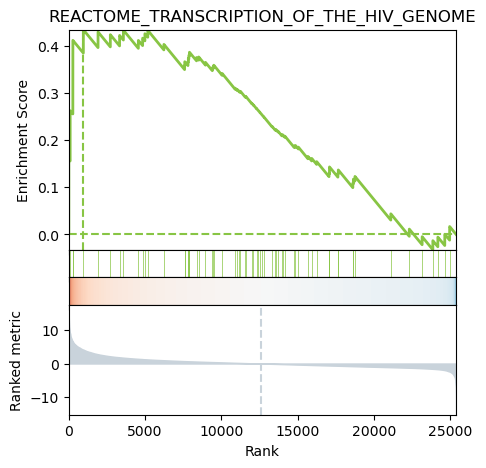

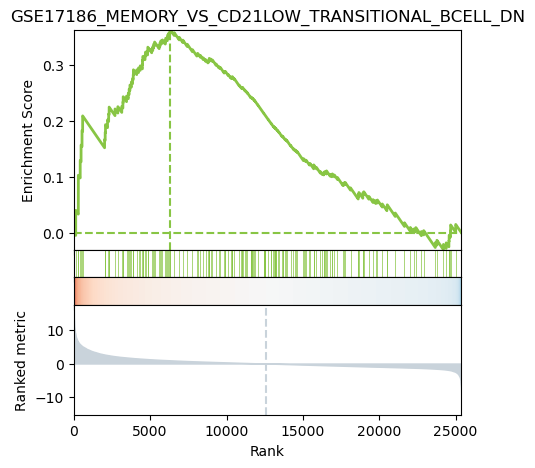

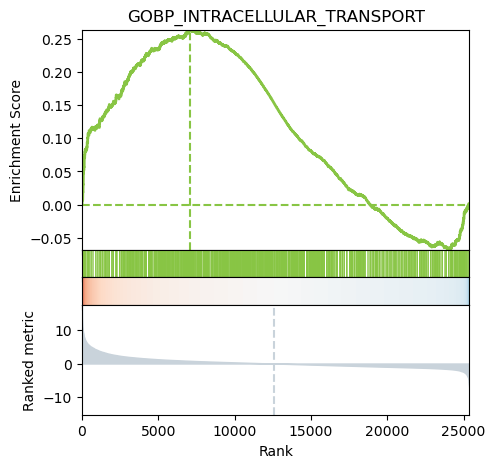

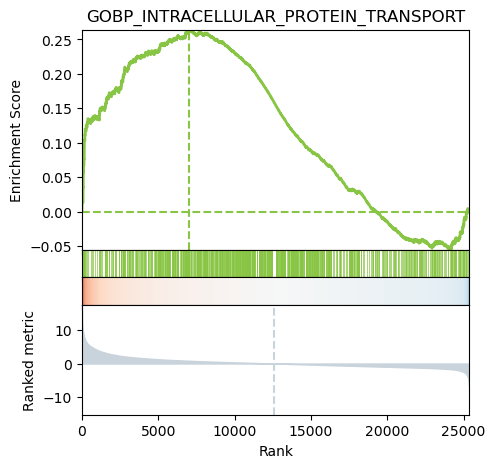

In [112]:
limit_GSEA=10
for file in files_list_gsea:
    filename=file['filename']
    score_file=file['path']
    pvalue_scores = file['scores']
    score_name='FDR p-value'
    #try:
    print(f"running {filename}")
    gsea_scores = pd.read_csv(score_file,index_col=0)
    terms_interest = gsea_scores[gsea_scores[score_name]>gsea_fdr]
    gsea_scores = pd.DataFrame(gsea_scores[score_name])
    print(f"{filename} has {len(terms_interest)} pathways enriched")
    terms_interest = terms_interest.sort_values(by=score_name, )
    limit = min(len(terms_interest), limit_GSEA)
    for term in terms_interest['Term'].to_list()[:limit]:
        print(f"{filename}: Checking term {term}")
        fig, ax = plot_gsea_results(gsea_scores=pvalue_scores, score_name='stat', msigdb=msigdb_extended, term=term)
        fig.savefig(f"GSEA_{filename}_{term}.png")
    #except Exception as e:
    #    print(e)
    #    pass

In [88]:
get_gsea_figure(filename,score_file,score_name,msigdb_extended,'MORF_CSNK2B')

ValueError: No sources with more than min_n=0 targets. Make sure mat and net have shared target features or
        reduce the number assigned to min_n

In [83]:
terms=[]
for file in files_list_gsea:
    terms.extend(get_terms_interest(file['filename'], file['path']))


In [84]:
len(set(terms))

1858

In [90]:
string_counts = Counter(terms)

# Keep only elements that repeat at least once
repeated_elements = [item for item in terms if string_counts[item] > 1]

# Remove duplicates from the result to keep only unique repeated elements
unique_repeated_elements = list(set(repeated_elements))
len(unique_repeated_elements)

119

In [87]:
unique_repeated_elements2

['STEIN_ESRRA_TARGETS_UP',
 'GOBP_ATP_METABOLIC_PROCESS',
 'GOMF_PRIMARY_ACTIVE_TRANSMEMBRANE_TRANSPORTER_ACTIVITY',
 'MOOTHA_PGC',
 'MORF_SOD1',
 'MOOTHA_HUMAN_MITODB_6_2002',
 'MORF_CSNK2B',
 'HALLMARK_OXIDATIVE_PHOSPHORYLATION',
 'MOOTHA_MITOCHONDRIA']

In [79]:
def create_GSEA_pdf(files_list, output_file, terms,msigdb,title="GSEA results"):
    with PdfPages(output_file) as pdf:
        # Create the index page
        fig, ax = plt.subplots(figsize=(8.5, 11))  # Letter size page
        
        ax.set_frame_on(False)
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Title for the index
        ax.text(0.5, 0.95, title, ha='center', fontsize=16, fontweight='bold')
        
        # Generate index with clickable links (not yet, just a visual index)
        y_position = 0.9
        for i, file_dict in enumerate(files_list):
            # Add gene name to the index
            name=file_dict['filename']
            ax.text(0.1, y_position - (i * 0.04), f"{i+1}. {name}", fontsize=12, ha='left')
        
        # Save index page
        pdf.savefig(fig)
        plt.close(fig)

        # Create violin plots for each gene using the modified function
        for term in terms:
            print(term)
            for file_dict in files_list:
                filename= file_dict['filename']
                path = file_dict['path']
                score_file= file_dict['score']
                score_name = file_dict['score_name']
                print(score_name)
                try:
                # Generate the violin plot and return the figure
                    fig = get_gsea_figure(filename,score_file,score_name,msigdb,term)
                    fig.suptitle(f"{filename}", fontsize=10, fontweight='bold')
                    
                except Exception as e:
                    print(f'fail in {filename}: {e}')
                    plt.close(fig)
                    continue
                # Save the figure to the PDF
                pdf.savefig(fig)
                
                # Close the figure after saving it to free up memory
                plt.close(fig)


In [ ]:
create_GSEA_pdf(files_list = files_list_gsea, output_file="../data/all_GSEA.pdf", terms=unique_repeated_elements,msigdb=msigdb_extended,title="GSEA results")


In [20]:
pwd

'/home/amore/work/notebooks'